# Wallet Intelligence: On-Chain Data Engineering from Raw Logs

**The whole notebook in one sentence: a blockchain is a public ledger that anyone can read, and once you can decode its receipts you can profile every wallet on it with nothing but free tools.** By the end you will have read live Ethereum data straight off a public node, decoded raw ERC-20 `Transfer` events (the standard "value moved" announcement a token emits) with their ABI, built a per-wallet feature table from scratch, and measured how concentrated a major token's flow really is.

Each section follows the same rhythm: synthetic example first, real chain second, what to infer third.

**What we will cover**
1. The raw materials: blocks as ledger pages, transactions as entries, logs as receipts
2. The ABI as the decoder ring: decoding ERC-20 `Transfer` events, synthetic first
3. From edges to nodes: engineering a per-wallet feature table
4. Concentration: Lorenz curves, the Gini coefficient, and who actually moves a token
5. Behaviour: activity rhythms and wallet roles
6. Applied downstream: from concentration numbers to actionable rules
7. Research discipline: point-in-time data, leakage, survivorship and the other traps
8. Caveats and where to go next

A **Further reading and resources** section at the end collects the canonical specifications, papers and documentation behind every technique used here.

> **Data:** Ethereum mainnet via a **free, keyless public JSON-RPC** endpoint. No account, no API key, no paid feed. We deliberately read a *small, recent* block range, so the whole notebook runs in a couple of minutes and caches its result for instant re-runs.
>
> **Nothing here is financial advice.** It is an educational walkthrough of how on-chain data is actually shaped and how you turn it into features.


In [1]:
# --- Setup -------------------------------------------------------------------
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from web3 import Web3

sys.path.append(str(Path.cwd().parent))          # so we can import src/
from src.data import (connect, get_logs, decode_transfers, load_or_fetch_transfers,
                      TRANSFER_TOPIC, ERC20_TRANSFER_ABI)
from src.style import use_house_style, PALETTE, titled

warnings.filterwarnings("ignore")
use_house_style()
ASSETS = Path.cwd().parent / "assets"; ASSETS.mkdir(exist_ok=True)
def save(fig, name): fig.savefig(ASSETS / name); return fig

## 1. The raw materials: blocks, transactions, logs and events

**Ethereum is an append-only ledger: a book of numbered pages that the whole world shares and nobody can quietly edit.** Forget crypto for a moment and picture an old-fashioned shop ledger. Each page (a **block**) holds an ordered list of entries (**transactions**). The page is dated, and when it is full the bookkeeper starts the next one. The chain part is the anti-tamper trick: every new page begins with a condensed fingerprint of the page before it. Rewrite an old page and its fingerprint changes, which visibly breaks every later page.

That is what lets thousands of strangers agree on a single history without trusting each other. Alter even one byte of any past block and every fingerprint from that block forward changes, so the chain of fingerprints makes the tampering obvious. The fingerprint comes from a cryptographic **hash function** -- a fixed recipe that turns any input into a short, fixed-length code (the digest). Two properties make the guarantee hold:

* **One-way**: given the digest alone, finding the input is computationally infeasible.
* **Collision-resistant**: finding two distinct inputs that produce the same digest is computationally infeasible.

Ethereum uses **Keccak-256**, which maps any input to a 32-byte (256-bit) digest. Formally:

$$H = \text{Keccak-256}(m)$$

where $m$ is any byte string and $H \in \{0,1\}^{256}$ is the digest -- a 256-bit number, usually written as 64 hexadecimal characters.


### The Keccak-256 function: input to digest

The diagram below shows what Keccak-256 does, using the ERC-20 Transfer event signature as the input. This hash is the universal "barcode" we use shortly to find token transfers.

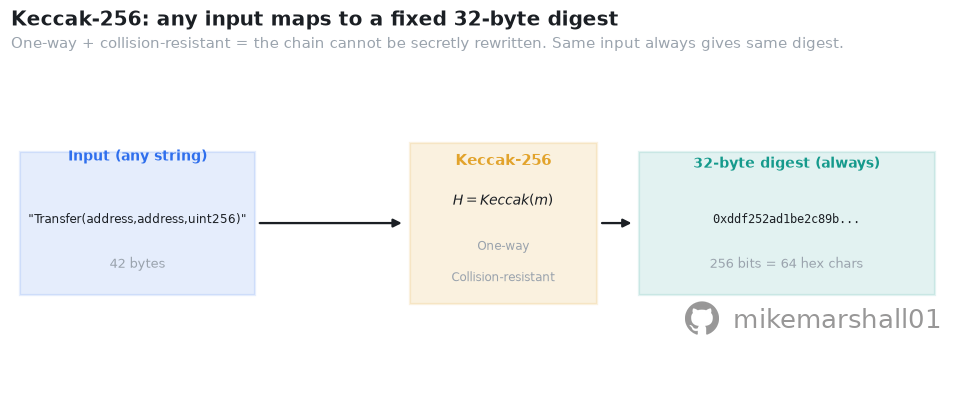

In [2]:
# --- Keccak-256 concept diagram -----------------------------------------------
sig_str = "Transfer(address,address,uint256)"
sig_hash = "0x" + Web3.keccak(text=sig_str).hex()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.set_xlim(0, 10); ax.set_ylim(0, 3.6); ax.axis("off")

# Input box
ax.add_patch(plt.Rectangle((0.1, 1.0), 2.5, 1.6,
             facecolor=PALETTE["blue"], alpha=0.12,
             edgecolor=PALETTE["blue"], linewidth=1.5))
ax.text(1.35, 2.5, "Input (any string)", ha="center", fontsize=9,
        color=PALETTE["blue"], weight="bold")
ax.text(1.35, 1.8, f'"{sig_str}"', ha="center", fontsize=8, color=PALETTE["ink"])
ax.text(1.35, 1.3, "42 bytes", ha="center", fontsize=8.5, color=PALETTE["grey"])

# Arrow
ax.annotate("", xy=(4.2, 1.8), xytext=(2.62, 1.8),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE["ink"], lw=1.5))

# Function box
ax.add_patch(plt.Rectangle((4.25, 0.9), 2.0, 1.8,
             facecolor=PALETTE["amber"], alpha=0.15,
             edgecolor=PALETTE["amber"], linewidth=1.5))
ax.text(5.25, 2.45, "Keccak-256", ha="center", fontsize=10, weight="bold",
        color=PALETTE["amber"])
ax.text(5.25, 2.0, "$H = \\mathit{Keccak}(m)$", ha="center", fontsize=9,
        color=PALETTE["ink"])
ax.text(5.25, 1.5, "One-way", ha="center", fontsize=8, color=PALETTE["grey"])
ax.text(5.25, 1.15, "Collision-resistant", ha="center", fontsize=8,
        color=PALETTE["grey"])

# Arrow
ax.annotate("", xy=(6.65, 1.8), xytext=(6.27, 1.8),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE["ink"], lw=1.5))

# Output box
ax.add_patch(plt.Rectangle((6.7, 1.0), 3.15, 1.6,
             facecolor=PALETTE["teal"], alpha=0.12,
             edgecolor=PALETTE["teal"], linewidth=1.5))
ax.text(8.27, 2.42, "32-byte digest (always)", ha="center", fontsize=9,
        color=PALETTE["teal"], weight="bold")
short_hash = sig_hash[:18] + "..."
ax.text(8.27, 1.8, short_hash, ha="center", fontsize=8,
        color=PALETTE["ink"], family="monospace")
ax.text(8.27, 1.3, "256 bits = 64 hex chars", ha="center", fontsize=8.5,
        color=PALETTE["grey"])

titled(ax, "Keccak-256: any input maps to a fixed 32-byte digest",
       "One-way + collision-resistant = the chain cannot be secretly rewritten. "
       "Same input always gives same digest.")
save(fig, "01_keccak_diagram.png"); plt.show()

Entries on their own are terse: "account A sent this much to address B and paid this fee". The richer record comes from receipts. When a transaction runs a **smart contract** (a program stored on the chain), the contract can **emit events**: small, structured announcements such as "I just moved 100 tokens from A to B". These are written into the block as **logs**. Logs are the workhorse of on-chain analytics for two reasons: contracts emit them cheaply, and nodes index them, so we can query by emitter and event type without re-running everything else in the block.

Each log has three parts, worth memorising because this whole notebook turns on them:

* an **address**: which contract wrote the receipt (for a token transfer, the token's own contract);
* up to four **topics**: indexed, searchable fields. `topics[0]` is always the *event signature hash*, a Keccak-256 fingerprint of the event's name and argument types; the remaining topics hold whichever arguments the contract marked `indexed`;
* a **data** blob: the non-indexed arguments, as ABI-encoded bytes.

We never need to scan whole blocks. We ask the node one filtered question via `eth_getLogs`: "give me every log from *this* contract whose `topics[0]` is *this* signature, between *these* blocks". That single call is the foundation of the entire notebook.

The schematic below is illustrative, not real data: three ledger pages chained by fingerprints, with one transaction expanded to show the receipt it emitted.

> **Key takeaway.** Blocks are ledger pages, transactions are the entries, logs are receipts stapled to the entries, and `eth_getLogs` is the index that lets you pull only the receipts you care about. A **node** is a computer running the Ethereum software and holding a copy of the ledger. **JSON-RPC** is the plain request-and-response protocol it speaks, the same style of interface as any web API.


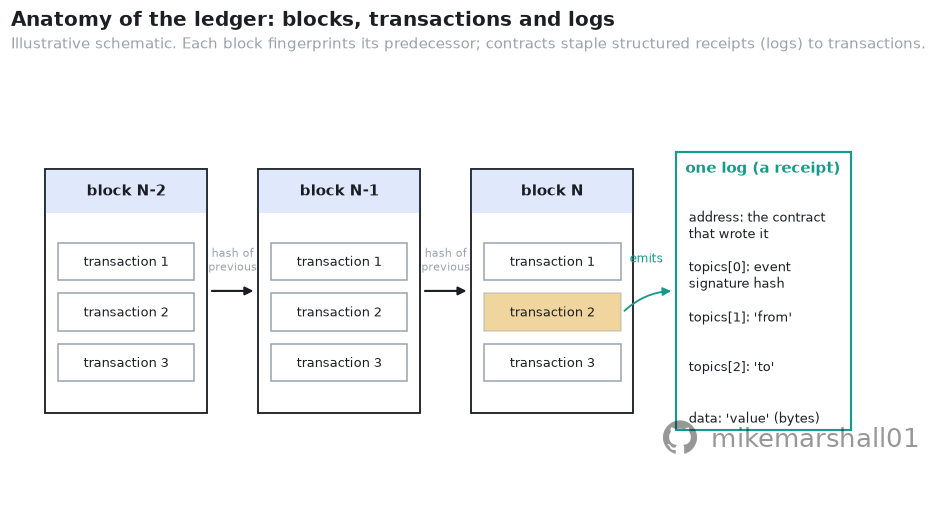

In [3]:
# --- Schematic: blocks -> transactions -> logs (illustrative, drawn by hand) --
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 5.4); ax.axis("off")

def draw_block(x, label, highlight_tx=None):
    ax.add_patch(plt.Rectangle((x, 1.1), 1.9, 3.0, facecolor="white",
                               edgecolor=PALETTE["ink"], linewidth=1.2, zorder=2))
    ax.add_patch(plt.Rectangle((x, 3.55), 1.9, 0.55, facecolor=PALETTE["blue"],
                               edgecolor="none", alpha=0.15, zorder=2))
    ax.text(x + 0.95, 3.82, label, ha="center", va="center", fontsize=10,
            weight="bold", zorder=3)
    for i in range(3):
        y = 2.95 - i * 0.62
        hl = (highlight_tx == i)
        ax.add_patch(plt.Rectangle((x + 0.15, y - 0.22), 1.6, 0.46,
                                   facecolor=PALETTE["amber"] if hl else "white",
                                   alpha=0.45 if hl else 1.0,
                                   edgecolor=PALETTE["grey"], zorder=3))
        ax.text(x + 0.95, y, f"transaction {i + 1}", ha="center", va="center",
                fontsize=8.5, color=PALETTE["ink"], zorder=4)

draw_block(0.4, "block N-2")
draw_block(2.9, "block N-1")
draw_block(5.4, "block N", highlight_tx=1)
for x0 in (2.32, 4.82):
    ax.annotate("", xy=(x0 + 0.56, 2.6), xytext=(x0, 2.6),
                arrowprops=dict(arrowstyle="-|>", color=PALETTE["ink"], lw=1.4))
    ax.text(x0 + 0.28, 2.85, "hash of\nprevious", ha="center", fontsize=7.5,
            color=PALETTE["grey"])

# The expanded receipt (one log) emitted by the highlighted transaction.
ax.add_patch(plt.Rectangle((7.8, 0.9), 2.05, 3.4, facecolor="white",
                           edgecolor=PALETTE["teal"], linewidth=1.4, zorder=2))
ax.text(8.82, 4.05, "one log (a receipt)", ha="center", fontsize=9.5,
        weight="bold", color=PALETTE["teal"])
for i, line in enumerate(["address: the contract\nthat wrote it",
                          "topics[0]: event\nsignature hash",
                          "topics[1]: 'from'",
                          "topics[2]: 'to'",
                          "data: 'value' (bytes)"]):
    ax.text(7.95, 3.6 - i * 0.62, line, fontsize=8.2, va="top")
ax.annotate("", xy=(7.78, 2.6), xytext=(7.17, 2.33),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE["teal"], lw=1.2,
                            connectionstyle="arc3,rad=-0.2"))
ax.text(7.45, 2.95, "emits", fontsize=8, color=PALETTE["teal"], ha="center")

titled(ax, "Anatomy of the ledger: blocks, transactions and logs",
       "Illustrative schematic. Each block fingerprints its predecessor; "
       "contracts staple structured receipts (logs) to transactions.")
save(fig, "01_anatomy.png"); plt.show()

Now the real chain. `connect()` tries a short list of free public nodes and uses the first that answers.

In [4]:
w3 = connect()
head = w3.eth.block_number
latest = w3.eth.get_block("latest")
print(f"chain id           : {w3.eth.chain_id}")
print(f"head block         : {head:,}")
print(f"head block time    : {pd.to_datetime(latest['timestamp'], unit='s', utc=True)}")
print(f"txns in head block : {len(latest['transactions'])}")

connected to https://ethereum-rpc.publicnode.com  (head block 25,314,093)
chain id           : 1
head block         : 25,314,093
head block time    : 2026-06-14 06:59:35+00:00
txns in head block : 117


**Three numbers to check before you trust the node.** Whenever you connect to a data source, confirm two things first: that you are looking at the system you think you are, and that the data is as fresh as you think.

> **What to look for.** A `chain id` of **1** means Ethereum mainnet. Any other value and you are on a test network or a sister chain, where the data is worthless for mainnet analysis. The head block number sits in the tens of millions, and blocks arrive roughly every **12 seconds** (about 7,200 per day), so a head timestamp more than a minute or two old means the node is lagging. A typical block carries a few hundred transactions; single digits would suggest a node serving stale or partial data.

### The event signature: a barcode for "tokens moved"

**Standard forms are what make mass processing possible, and the event signature is the form number.** When every bank in a country uses the same direct-debit form, a clerk recognises and processes it at a glance, no matter who submitted it. The **ERC-20 standard** (proposed in EIP-20 in 2015) plays exactly that role for tokens: any contract claiming to be a standard token must emit the same event whenever value moves:

```solidity
event Transfer(address indexed from, address indexed to, uint256 value);
```

Keccak-256 hashes the signature string `Transfer(address,address,uint256)` into a fixed 32-byte fingerprint:

$$\text{topic}_0 = H\bigl(\underbrace{\texttt{"Transfer(address,address,uint256)"}}_{\text{event signature string}}\bigr)$$

where $H = \text{Keccak-256}$. Every compliant token writes that fingerprint into `topics[0]` of its transfer logs. This is the trick on which all multi-token analytics rests: because the form is standard, one hash finds transfers for **any** of the hundreds of thousands of ERC-20 tokens, with no per-token paperwork. Let us compute that fingerprint from scratch and check it against the constant our data module uses.


In [5]:
sig = "Transfer(address,address,uint256)"
h = Web3.keccak(text=sig).hex()
h = h[2:] if h.startswith("0x") else h           # normalise across web3 versions
print(f"event signature : {sig}")
print(f"keccak-256 hash : 0x{h}")
print(f"matches module  : {('0x' + h) == TRANSFER_TOPIC}")

event signature : Transfer(address,address,uint256)
keccak-256 hash : 0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef
matches module  : True


**Pitfalls worth knowing before you query anything.**

- **ERC-721 (NFT) transfers share the exact same signature string.** In ERC-721 all three arguments are `indexed`, so the `tokenId` moves into `topics[3]` and the data field is empty. Same `topics[0]`, different layout. If you query across many contracts rather than one token, check the topic count before decoding, or NFT movements will be silently misread as token amounts.
- **Not every token plays by the rules.** Rebasing tokens change balances without emitting transfers, fee-on-transfer tokens deliver less than the logged `value`, and some early tokens deviate from the standard in small, painful ways. The standard covers most of the market, not all of it.

> **What to look for.** A genuine ERC-20 transfer log has exactly **3 topics** and a 32-byte data field. **4 topics** with empty data means ERC-721. Anything else is non-standard and needs its own ABI.

> **Key takeaway.** One Keccak-256 hash of one standardised string is the barcode that finds token movements across the entire chain. Standards, not cleverness, are what make on-chain analytics scale.

## 2. Decoding: the ABI is the decoder ring

**Raw logs are just bytes -- a CSV without its header row -- and the ABI is the header row.** The **ABI** (Application Binary Interface) is a machine-readable description of each event: its name, its argument order and types, and which arguments are indexed (and therefore live in topics rather than data). Without it every number is present and correct but unreadable; with it the bytes resolve instantly into labelled fields.

The encoding convention is rigid and simple, which is what makes hand-decoding feasible: **every field is padded to 32 bytes**. An address is 20 bytes, so it is left-padded with 12 zero bytes. A `uint256` amount is one big-endian unsigned integer (most significant byte first, the same order you write ordinary numbers in).

### Synthetic first: a transfer we invent, encode, and decode by hand

The cleanest way to see decoding is on a log we manufacture ourselves, because then we know the right answer in advance and can verify the round trip exactly. Below we invent a sender, a receiver and an amount, encode them into topics and data the way a token contract would, then decode them back with nothing but string slicing. This synthetic log is purely illustrative; no chain involved.


In [6]:
# --- SYNTHETIC: build a fake Transfer log, then decode it ---------------------
fake_from  = "0x" + "ab" * 20                     # a made-up 20-byte address
fake_to    = "0x" + "cd" * 20                     # another
fake_value = 1_234_500_000                        # 1,234.50 tokens at 6 decimals

topic1 = fake_from[2:].rjust(64, "0")             # left-pad to 32 bytes (64 hex chars)
topic2 = fake_to[2:].rjust(64, "0")
data   = hex(fake_value)[2:].rjust(64, "0")       # one big-endian uint256

print("ENCODED (what a token contract would write)")
print(f"  topics[0] : {TRANSFER_TOPIC}   <- the Transfer barcode")
print(f"  topics[1] : 0x{topic1}")
print(f"  topics[2] : 0x{topic2}")
print(f"  data      : 0x{data}")

dec_from = "0x" + topic1[-40:]                    # last 20 bytes = the address
dec_to   = "0x" + topic2[-40:]
dec_val  = int(data, 16)                          # hex -> integer

print("\nDECODED (string slicing, no libraries)")
print(f"  from  : {dec_from}")
print(f"  to    : {dec_to}")
print(f"  value : {dec_val:,}  (= {dec_val / 10**6:,.2f} tokens at 6 decimals)")

assert dec_from == fake_from and dec_to == fake_to and dec_val == fake_value
print("\nround trip exact: what we encoded is precisely what we decoded")

ENCODED (what a token contract would write)
  topics[0] : 0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef   <- the Transfer barcode
  topics[1] : 0x000000000000000000000000abababababababababababababababababababab
  topics[2] : 0x000000000000000000000000cdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcd
  data      : 0x000000000000000000000000000000000000000000000000000000004994f9a0

DECODED (string slicing, no libraries)
  from  : 0xabababababababababababababababababababab
  to    : 0xcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcdcd
  value : 1,234,500,000  (= 1,234.50 tokens at 6 decimals)

round trip exact: what we encoded is precisely what we decoded


The planted `from`, `to` and `value` come back exactly, byte for byte. Decoding is mostly knowing *where each field lives* and *what type to read it as*, which is precisely the information an ABI carries. The layout below is the one picture to keep in your head.


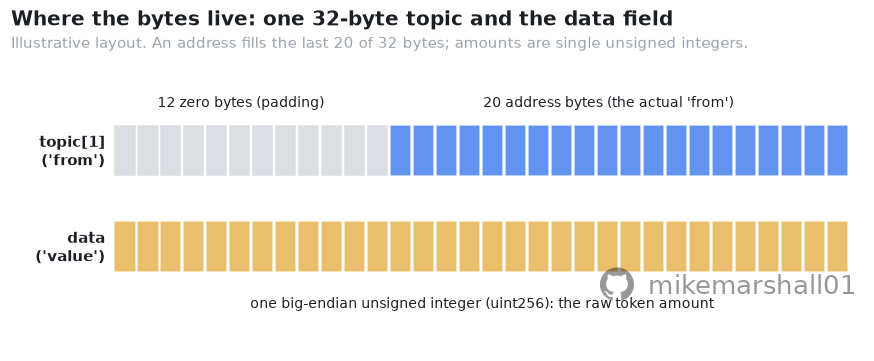

In [7]:
# --- Byte layout of one Transfer log field (illustrative) ---------------------
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.set_xlim(-4.5, 32.6); ax.set_ylim(-1.3, 3.5); ax.axis("off")
for i in range(32):
    pad = i < 12
    ax.add_patch(plt.Rectangle((i, 1.6), 0.92, 0.85,
                               facecolor=PALETTE["grey"] if pad else PALETTE["blue"],
                               alpha=0.35 if pad else 0.75, edgecolor="white"))
ax.text(5.5, 2.75, "12 zero bytes (padding)", ha="center", fontsize=9)
ax.text(21.5, 2.75, "20 address bytes (the actual 'from')", ha="center", fontsize=9)
ax.text(-0.4, 2.0, "topic[1]\n('from')", ha="right", va="center",
        fontsize=10, weight="bold")
for i in range(32):
    ax.add_patch(plt.Rectangle((i, 0.0), 0.92, 0.85,
                               facecolor=PALETTE["amber"], alpha=0.7, edgecolor="white"))
ax.text(16, -0.6, "one big-endian unsigned integer (uint256): the raw token amount",
        ha="center", fontsize=9)
ax.text(-0.4, 0.4, "data\n('value')", ha="right", va="center",
        fontsize=10, weight="bold")
titled(ax, "Where the bytes live: one 32-byte topic and the data field",
       "Illustrative layout. An address fills the last 20 of 32 bytes; "
       "amounts are single unsigned integers.")
save(fig, "01_topic_layout.png"); plt.show()

### The real thing: USDC transfers straight off the chain

We will follow **USDC**, a dollar-pegged stablecoin issued by Circle and one of the most-transferred tokens on Ethereum, over a small recent window. Its contract address is fixed and public:

> `0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48`

Our `load_or_fetch_transfers()` helper does four things, then caches the result so re-runs are instant:

1. asks the node for the current head block and looks back a fixed number of blocks;
2. calls `eth_getLogs` in safe, small windows (public nodes cap the range, so we paginate and shrink the window automatically if a provider complains);
3. **decodes** each raw log with the ERC-20 ABI, pulling `from` and `to` out of the indexed topics and `value` out of the data blob, exactly as we just did by hand;
4. attaches a UTC timestamp per block and scales the raw integer `value` into human units using the token's `decimals` (USDC has 6, so 1 USDC is stored as 1,000,000).

We use about 2,000 blocks, roughly 6-7 hours of Ethereum at ~12 seconds per block. That is plenty to learn from and small enough to be polite to a free endpoint.

In [8]:
USDC = "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48"
LOOKBACK = 2000

transfers, meta = load_or_fetch_transfers(USDC, lookback_blocks=LOOKBACK, chunk=400)
SYMBOL = meta["symbol"]
print(f"\n{meta['n_transfers']:,} {SYMBOL} transfers "
      f"over blocks {meta['from_block']:,}-{meta['to_block']:,} "
      f"({meta['decimals']} decimals)")
transfers.head(5)

loaded 202,617 cached transfers for USDC (blocks 25301836-25303835)

202,617 USDC transfers over blocks 25,301,836-25,303,835 (6 decimals)


,block,tx_hash,log_index,from,to,value,timestamp,amount
0,25301836,0xb087d6a7af3ad3132edcaadcf0781d10056b23a686bf...,7,0xe28fDF9d8779eA3b282c61F30E35358cbD291616,0x00000000008D5f1200332AF8A6813cb8377b5BFd,30000000000,2026-06-12 13:59:11+00:00,30000.000000
1,25301836,0xb087d6a7af3ad3132edcaadcf0781d10056b23a686bf...,8,0x00000000008D5f1200332AF8A6813cb8377b5BFd,0x2c158BC456e027b2AfFCCadF1BDBD9f5fC4c5C8c,29973209683,2026-06-12 13:59:11+00:00,29973.209683
2,25301836,0xb087d6a7af3ad3132edcaadcf0781d10056b23a686bf...,10,0x2c158BC456e027b2AfFCCadF1BDBD9f5fC4c5C8c,0x3312cc371Fe0Dd5171878630A1E5cf69778E8fa5,29973209683,2026-06-12 13:59:11+00:00,29973.209683
3,25301836,0x314a6001ed71bad810de13e627a791f288059aea38d4...,67,0x445F16314284b43DfA1FD3cD77B9dea4a1bEbd97,0xBCae28130a1d6b733dc106982B303874B4A05d56,100000000,2026-06-12 13:59:11+00:00,100.000000
4,25301836,0xe8e25c2c5d012f7e2a8048ac068ba41970d4dee946b9...,141,0xBcBa53bf254F3799A65215b36CE28975006CaFdb,0xAe39EfdBB5d8A50e7031b6F9F957d43CDFbAE72B,70000000000,2026-06-12 13:59:11+00:00,70000.000000


### One real log, raw then decoded

To close the loop between the synthetic exercise and the live chain, we fetch a single raw log and decode it. The raw form should look exactly like the layout chart above: the same barcode in `topics[0]`, the same zero-padding around the addresses.

In [9]:
sample = get_logs(w3, USDC, meta["to_block"] - 50, meta["to_block"], chunk=51)
raw = dict(sample[0])
print("RAW LOG (one event, as the node returns it)")
print(f"  address  : {raw['address']}")
print(f"  topic0   : {raw['topics'][0].hex()}   <- Transfer signature")
print(f"  topic1   : {raw['topics'][1].hex()}   <- 'from', left-padded to 32 bytes")
print(f"  topic2   : {raw['topics'][2].hex()}   <- 'to',   left-padded to 32 bytes")
print(f"  data     : {raw['data'].hex() if hasattr(raw['data'],'hex') else raw['data']}   <- 'value', uint256")

decoded_one = decode_transfers(w3, [sample[0]]).iloc[0]
print("\nDECODED (ABI applied)")
print(f"  from   : {decoded_one['from']}")
print(f"  to     : {decoded_one['to']}")
print(f"  value  : {decoded_one['value']:,}  (raw integer)")
print(f"  = {decoded_one['value'] / 10**meta['decimals']:,.2f} {SYMBOL}")

RAW LOG (one event, as the node returns it)
  address  : 0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48
  topic0   : ddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef   <- Transfer signature
  topic1   : 00000000000000000000000019787244cae35483c105d446ce60b30572e5eab3   <- 'from', left-padded to 32 bytes
  topic2   : 0000000000000000000000006928f3e126dbac9923d52300fdef714b280b305c   <- 'to',   left-padded to 32 bytes
  data     : 000000000000000000000000000000000000000000000000000000003ff20da2   <- 'value', uint256

DECODED (ABI applied)
  from   : 0x19787244CaE35483c105D446Ce60B30572E5eAb3
  to     : 0x6928F3e126dBac9923d52300fdeF714B280b305C
  value  : 1,072,827,810  (raw integer)
  = 1,072.83 USDC


**Once decoded, the chain is just a tidy table.** An exotic-looking data source collapses into an ordinary `(from, to, amount, when)` table, and everything downstream is ordinary data engineering. For crypto specifically, the two details that ruin real pipelines are both visible right here.

> **What to look for.** Exactly **3 topics** confirms a standard ERC-20 transfer. The **decimals** scaling is the single most common on-chain data bug: USDC stores 6 decimals where most tokens store 18, so the wrong divisor inflates or deflates every figure by a factor of 10^12. If your token volumes look a trillion times too large, this is why. Finally, transfers where `from` or `to` is the **zero address** (`0x000...0`) are mints and burns -- the token supply changing, not one user paying another. Serious flow analysis treats them separately.


In [10]:
# A quick, honest summary of what we actually pulled.
span_seconds = (transfers["timestamp"].max() - transfers["timestamp"].min()).total_seconds()
print(f"window           : {transfers['timestamp'].min()}  ->  {transfers['timestamp'].max()}")
print(f"wall-clock span  : {span_seconds/3600:.1f} hours")
print(f"transfers        : {len(transfers):,}")
print(f"unique senders   : {transfers['from'].nunique():,}")
print(f"unique receivers : {transfers['to'].nunique():,}")
print(f"total volume     : {transfers['amount'].sum():,.0f} {SYMBOL}")

window           : 2026-06-12 13:59:11+00:00  ->  2026-06-12 20:40:23+00:00
wall-clock span  : 6.7 hours
transfers        : 202,617
unique senders   : 50,436
unique receivers : 59,727
total volume     : 22,562,018,541 USDC


Thousands of distinct addresses and tens of billions of dollars in an afternoon, reconstructed from public receipts by a script with no API key. Every figure is traceable to a specific log in a specific block. That auditability is the genuinely new thing about on-chain data relative to traditional finance, where flows of this kind are proprietary.

Every number in this notebook describes *these hours*, not USDC in general. State the window before quoting any statistic.

> **Key takeaway.** The ABI turns bytes into a ledger you can audit row by row. From here on, no crypto-specific machinery is needed, just disciplined pandas.


## 3. From edges to nodes: the per-wallet feature table

**A transfer list describes events; analytics needs actors. So the core move is to collapse many event rows into one row per wallet.** Loyalty schemes, telecoms operators and fraud teams all live on the same trick, because individual events are noisy while profiles are interpretable.

In graph language, transfers are **edges** (arrows from one address to another) and wallets are **nodes**; feature engineering collapses edges into node descriptions.

### The transformation illustrated: edge-list to feature table

The schematic below makes the transformation concrete. Each row on the left is one transfer event. Collapse all events for a given wallet and you get the feature row on the right -- one row per actor, not one row per event.


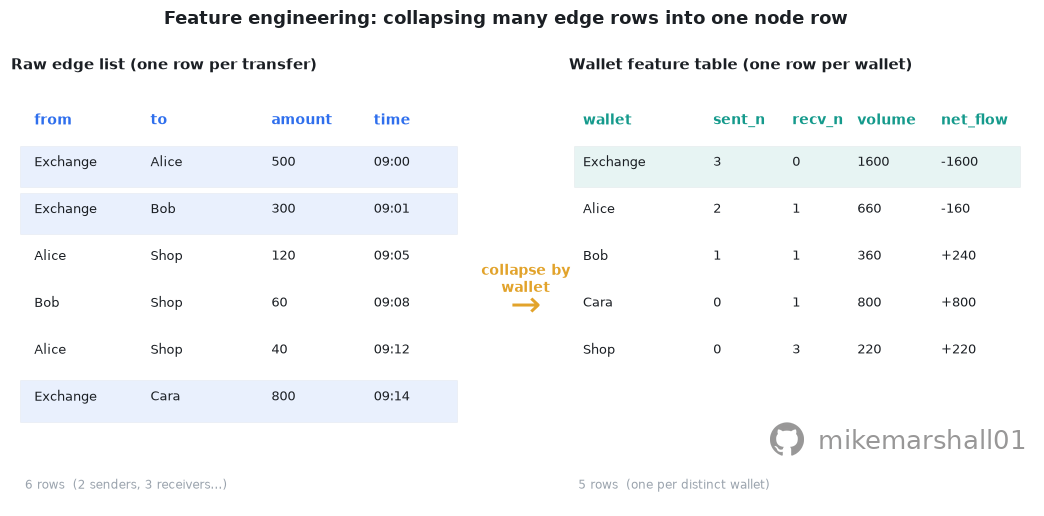

In [11]:
# --- Edge-to-node transformation schematic (illustrative) --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))

ax_l, ax_r = axes
ax_l.axis("off"); ax_r.axis("off")

# Left panel: raw edge-list
ax_l.set_xlim(0, 10); ax_l.set_ylim(0, 6.5)
ax_l.set_title("Raw edge list (one row per transfer)", loc="left",
               fontsize=10, fontweight="bold", pad=8)

edge_cols = ["from", "to", "amount", "time"]
edge_rows = [
    ["Exchange", "Alice", "500", "09:00"],
    ["Exchange", "Bob",   "300", "09:01"],
    ["Alice",    "Shop",  "120", "09:05"],
    ["Bob",      "Shop",  "60",  "09:08"],
    ["Alice",    "Shop",  "40",  "09:12"],
    ["Exchange", "Cara",  "800", "09:14"],
]
col_xs = [0.5, 3.0, 5.6, 7.8]
header_y = 5.9
row_h = 0.72
for ci, col in enumerate(edge_cols):
    ax_l.text(col_xs[ci], header_y, col, fontsize=9, weight="bold",
              color=PALETTE["blue"], va="center")
for ri, row in enumerate(edge_rows):
    y = header_y - (ri + 1) * row_h
    bg = PALETTE["blue"] if row[0] == "Exchange" else "white"
    alpha = 0.10 if row[0] == "Exchange" else 0.0
    ax_l.add_patch(plt.Rectangle((0.2, y - 0.3), 9.4, row_h * 0.88,
                                 facecolor=bg, alpha=alpha,
                                 edgecolor=PALETTE["grey"], linewidth=0.6))
    for ci, val in enumerate(row):
        ax_l.text(col_xs[ci], y + 0.08, val, fontsize=8.8, va="center",
                  color=PALETTE["ink"])
ax_l.text(0.3, 0.25, "6 rows  (2 senders, 3 receivers...)", fontsize=8,
          color=PALETTE["grey"])

# Arrow between panels
fig.text(0.515, 0.52, "collapse by\nwallet",
         ha="center", va="center", fontsize=9, color=PALETTE["amber"],
         fontweight="bold")
fig.text(0.515, 0.47, u"→", ha="center", va="center", fontsize=24,
         color=PALETTE["amber"])

# Right panel: one row per wallet
ax_r.set_xlim(0, 10); ax_r.set_ylim(0, 6.5)
ax_r.set_title("Wallet feature table (one row per wallet)", loc="left",
               fontsize=10, fontweight="bold", pad=8)

feat_cols  = ["wallet", "sent_n", "recv_n", "volume", "net_flow"]
feat_rows = [
    ["Exchange", "3", "0", "1600", "-1600"],
    ["Alice",    "2", "1", "660",  "+340"],
    ["Bob",      "1", "1", "360",  "+240"],
    ["Cara",     "0", "1", "800",  "+800"],
    ["Shop",     "0", "3", "220",  "+220"],
]
fcol_xs = [0.3, 3.1, 4.8, 6.2, 8.0]
for ci, col in enumerate(feat_cols):
    ax_r.text(fcol_xs[ci], header_y, col, fontsize=9, weight="bold",
              color=PALETTE["teal"], va="center")
for ri, row in enumerate(feat_rows):
    y = header_y - (ri + 1) * row_h
    bg = PALETTE["teal"] if row[0] == "Exchange" else "white"
    alpha = 0.10 if row[0] == "Exchange" else 0.0
    ax_r.add_patch(plt.Rectangle((0.1, y - 0.3), 9.6, row_h * 0.88,
                                 facecolor=bg, alpha=alpha,
                                 edgecolor=PALETTE["grey"], linewidth=0.6))
    for ci, val in enumerate(row):
        ax_r.text(fcol_xs[ci], y + 0.08, val, fontsize=8.8, va="center",
                  color=PALETTE["ink"])
ax_r.text(0.2, 0.25, "5 rows  (one per distinct wallet)", fontsize=8,
          color=PALETTE["grey"])

fig.suptitle("Feature engineering: collapsing many edge rows into one node row",
             fontsize=12, fontweight="bold", y=1.01)
save(fig, "01_edge_to_node.png"); plt.show()

Exchange sends three times and never receives: a pure **distributor**. Shop receives three times and never sends: a pure **collector**. The transformation reduces noise and makes actors, not events, the unit of analysis.

For every wallet we compute a small, interpretable set of features. This is the kind of table that feeds clustering, labelling ("is this an exchange?") or anomaly detection downstream:

* **sent / received counts and amounts**: raw activity and its direction;
* **unique counterparties**: a hub touching thousands of wallets behaves very differently from one that talks to a handful;
* **active timespan**: first seen to last seen, a crude lifespan within our window;
* **net flow**: received minus sent, separating accumulators from distributors.

### Synthetic first: a toy ledger you can audit by hand

Before trusting the function on tens of thousands of real transfers, we run it on a toy ledger of five named wallets and eight transfers. It is small enough to check every output number against the inputs by mental arithmetic. The data below is invented for illustration.


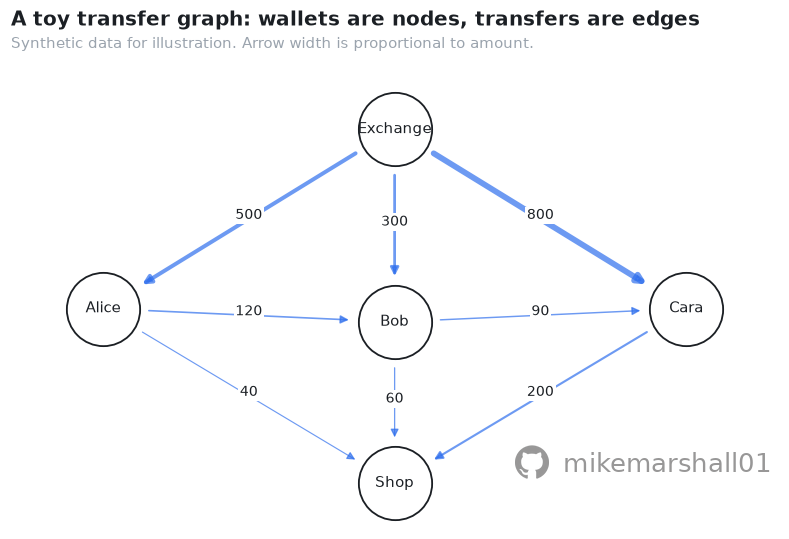

,tx_count,volume,net_flow,counterparties,active_minutes
from,,,,,
Exchange,3.0,1600.0,-1600.0,3,2.0
Cara,3.0,1090.0,690.0,3,5.0
Alice,3.0,660.0,340.0,3,6.0
Bob,4.0,570.0,270.0,4,6.0
Shop,3.0,300.0,300.0,3,2.0


In [12]:
def wallet_features(df: pd.DataFrame) -> pd.DataFrame:
    """One row per wallet with simple, interpretable on-chain features."""
    sent = df.groupby("from").agg(
        sent_count=("value", "size"),
        sent_amount=("amount", "sum"),
        sent_to_n=("to", "nunique"),
        first_sent=("timestamp", "min"),
        last_sent=("timestamp", "max"),
    )
    recv = df.groupby("to").agg(
        recv_count=("value", "size"),
        recv_amount=("amount", "sum"),
        recv_from_n=("from", "nunique"),
        first_recv=("timestamp", "min"),
        last_recv=("timestamp", "max"),
    )
    feat = sent.join(recv, how="outer")
    count_cols = ["sent_count", "sent_amount", "sent_to_n",
                  "recv_count", "recv_amount", "recv_from_n"]
    feat[count_cols] = feat[count_cols].fillna(0)

    feat["tx_count"] = feat["sent_count"] + feat["recv_count"]
    feat["volume"] = feat["sent_amount"] + feat["recv_amount"]
    feat["net_flow"] = feat["recv_amount"] - feat["sent_amount"]

    first = feat[["first_sent", "first_recv"]].min(axis=1)
    last = feat[["last_sent", "last_recv"]].max(axis=1)
    feat["first_seen"] = first
    feat["last_seen"] = last
    feat["active_minutes"] = (last - first).dt.total_seconds() / 60.0

    # Unique counterparties: union of who they sent to and received from. The outer join
    # leaves a NaN (a float) wherever a wallet only ever sent or only ever received, so we
    # coerce anything that is not a set to an empty set before taking the union.
    cp = (df.groupby("from")["to"].apply(set).rename("cp_out")
            .to_frame()
            .join(df.groupby("to")["from"].apply(set).rename("cp_in"), how="outer"))
    def _as_set(x):
        return x if isinstance(x, set) else set()
    cp["counterparties"] = cp.apply(
        lambda r: len(_as_set(r["cp_out"]) | _as_set(r["cp_in"])), axis=1)
    feat = feat.join(cp["counterparties"])

    return feat.sort_values("volume", ascending=False)

# --- SYNTHETIC toy ledger: 5 wallets, 8 transfers (illustrative) -------------
toy = pd.DataFrame([
    ("Exchange", "Alice", 500), ("Exchange", "Bob", 300), ("Exchange", "Cara", 800),
    ("Alice", "Bob", 120), ("Bob", "Shop", 60), ("Cara", "Shop", 200),
    ("Alice", "Shop", 40), ("Bob", "Cara", 90),
], columns=["from", "to", "amount"])
toy_tx = toy.assign(
    value=lambda d: (d["amount"] * 10**6).astype(int),
    timestamp=pd.to_datetime("2026-01-01", utc=True)
              + pd.to_timedelta(range(len(toy)), unit="min"))

pos = {"Exchange": (0.50, 0.85), "Alice": (0.12, 0.45), "Bob": (0.50, 0.42),
       "Cara": (0.88, 0.45), "Shop": (0.50, 0.06)}
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_xlim(0, 1); ax.set_ylim(-0.04, 1); ax.axis("off")
for _, r in toy.iterrows():
    x0, y0 = pos[r["from"]]; x1, y1 = pos[r["to"]]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=PALETTE["blue"],
                                lw=0.6 + r["amount"] / 250, alpha=0.7,
                                shrinkA=30, shrinkB=30))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, f"{r['amount']}",
            fontsize=9, ha="center", color=PALETTE["ink"],
            bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
for name, (x, y) in pos.items():
    ax.scatter([x], [y], s=2300, color="white",
               edgecolor=PALETTE["ink"], zorder=3, linewidth=1.2)
    ax.text(x, y, name, ha="center", va="center", zorder=4, fontsize=9.5)
titled(ax, "A toy transfer graph: wallets are nodes, transfers are edges",
       "Synthetic data for illustration. Arrow width is proportional to amount.")
save(fig, "01_toy_ledger.png"); plt.show()

toy_feat = wallet_features(toy_tx)
toy_feat[["tx_count", "volume", "net_flow", "counterparties", "active_minutes"]].round(1)

Exchange sends three times and never receives, so its net flow is strongly negative: a pure **distributor**. Shop receives three times and never sends: a pure **collector**. Bob both sends and receives, with the most counterparties relative to his size: a **pass-through** node. Every figure is verifiable by adding up at most three numbers.

If a feature pipeline cannot survive an audit this small, it cannot be trusted at a million rows. This verify-on-toy-data habit catches sign errors (net flow backwards), join bugs (lost send-only wallets) and unit errors before they pollute real work.

Now the same function on the real USDC window.


In [13]:
wallets = wallet_features(transfers)
print(f"{len(wallets):,} distinct wallets in the window")
wallets[["tx_count", "volume", "net_flow", "counterparties",
         "active_minutes"]].head(8).round(2)

71,456 distinct wallets in the window


,tx_count,volume,net_flow,counterparties,active_minutes
from,,,,,
0xBBBBBbbBBb9cC5e90e3b3Af64bdAF62C37EEFFCb,2003.0,1.248803e+10,6604029.82,174,400.0
0x06CFf7088619C7178F5e14f0B119458d08d2f5ef,796.0,7.654036e+09,0.00,52,398.2
0x55FE002aefF02F77364de339a1292923A15844B8,567.0,1.599894e+09,-5314954.31,194,400.2
0xd226997439ecfBEfF8E110C8C78c8a7Eefd19f89,158.0,1.434000e+09,0.00,35,391.0
0xA9D1e08C7793af67e9d92fe308d5697FB81d3E43,5087.0,1.223721e+09,14103864.97,3688,400.4
0x0000000000000000000000000000000000000000,1393.0,1.019278e+09,80715193.72,340,400.6
0x00000000000762339537BD0FD01e44F661bD8f67,61.0,9.297450e+08,0.06,21,370.0
0xEe7aE85f2Fe2239E27D9c1E23fFFe168D63b4055,6677.0,9.280154e+08,80691716.73,5386,401.0


**A handful of hubs and a long tail.** The busiest wallets here touch thousands of unique counterparties inside a few hours; the median wallet appears once or twice. That shape is not crypto-specific -- telephone call records, payment networks and shop foot traffic all look the same. But in crypto the hubs are almost certainly *contracts and exchange infrastructure*, not people: hot wallets, market makers, routers, bridges and the token's own treasury.

The long tail is closer to end users, though even there many addresses are bots.

> **What to look for.** A wallet touching **thousands of unique counterparties within hours** is infrastructure, full stop; no human transacts like that. Counterparty counts below ~5 with one or two transfers mark the retail tail. A large positive net flow flags an accumulator or deposit sink; large negative, a distributor. An active span covering essentially the whole window without pause suggests an automated process rather than a person.

> **Key takeaway.** Collapse edges into node profiles and on-chain data becomes ordinary customer analytics. Validate the collapsing function on data small enough to audit by hand before pointing it at the chain.


## 4. Concentration: who actually moves the token

**Intuition says many actors share the work; the data says otherwise.** Concentration measures how much of the action depends on how few actors, and almost every real system is far more concentrated than a naive guess suggests. It matters for three reasons. Averages mislead under concentration (the "average customer" describes nobody). Sampling a few actors can misrepresent the whole. And a concentrated system is fragile: lose two or three key actors and the activity goes with them. The pattern shows up across domains -- the 80/20 rule is a rough summary -- but the precise degree of concentration varies, and that variation is the signal.

### The Lorenz curve

Which fraction of senders accounts for the bulk of volume? Economists built the answer a century ago. Sort wallets from largest to smallest volume, then ask: what share of total volume do the top 1% account for? The top 10%? The top 50%? Plot those cumulative fractions and you have the **Lorenz curve** (Lorenz 1905). Formally:

$$L(p) = \frac{\sum_{i=1}^{\lfloor np \rfloor} v_{(i)}}{\sum_{i=1}^{n} v_{(i)}}$$

where:
- $n$ is the total number of wallets,
- $p \in [0, 1]$ is the cumulative share of wallets (e.g. $p = 0.01$ is the top 1%),
- $v_{(i)}$ is the volume of the $i$-th wallet when sorted **largest first**,
- $L(p)$ is the cumulative fraction of total volume accounted for by the top $p$ fraction of wallets.

When every wallet has identical volume, $L(p) = p$ and the curve is the diagonal. When one wallet has everything, $L(p) = 0$ for $p < 1$ and $L(1) = 1$: a step function at the right edge. Real curves lie between these extremes and bow **above** the diagonal (in our largest-first convention) by an amount proportional to concentration.

### The Gini coefficient

The Lorenz curve is a picture, and to compare tokens or time periods we need a single number. The **Gini coefficient** (Gini 1912) is that number. It is the area between the Lorenz curve and the diagonal, doubled. In the continuous case:

$$G = 1 - 2\int_0^1 \tilde{L}(p)\,dp$$

where $\tilde{L}(p)$ is the **standard (smallest-first) Lorenz curve** ($\tilde{L}(p) \leq p$). The integral computes the area under $\tilde{L}(p)$; subtracting from 1 and doubling gives the area *between* $\tilde{L}(p)$ and the perfect-equality line. This equals 0 when $\tilde{L}(p) = p$ everywhere (perfect equality) and approaches 1 as $\tilde{L}(p)$ approaches the step function (one actor has everything).

**In plain words:** sum up the cumulative volume shares at each rank, multiply by 2, and subtract from $(n+1)/n$. A Gini near 0 says every wallet moves a similar amount; a Gini near 1 says one wallet dominates.

In the discrete case -- a finite list of $n$ wallets with volumes $v_1, \ldots, v_n$ sorted in ascending order -- the integral becomes a sum. With $V = \sum_i v_i$:

$$G = \frac{n + 1 - 2\,\displaystyle\sum_{i=1}^{n}\frac{\sum_{j=1}^{i} v_j}{V}}{n}$$

where:
- $n$ = number of wallets,
- $v_j$ = volume of wallet $j$ (sorted ascending: smallest first),
- $\sum_{j=1}^{i} v_j$ = cumulative volume up to rank $i$,
- $V = \sum_j v_j$ = total volume across all wallets,
- $\frac{\sum_{j=1}^{i} v_j}{V}$ = the cumulative share $\tilde{L}(i/n)$ at each rank,
- the outer division by $n$ normalises so $G \in [0, 1)$.

One presentational choice to note. The classic Lorenz curve ranks actors smallest first, so it bows *below* the diagonal. We rank **largest first**, so our curves bow *above* the diagonal and read directly as the headline statistic: "the top x% of senders moved y% of the volume". Same information, more natural reading for flow data.

### Synthetic first: calibrating your eye and seeing the Gini as an area

Before the real curve, three synthetic populations with known characters, so you know what even, moderately skewed and extremely skewed actually look like in this format. Critically, the plot below **shades the area** that the Gini measures: the region between the Lorenz curve and the diagonal. A large shaded area = a large Gini. All three populations are invented for illustration.


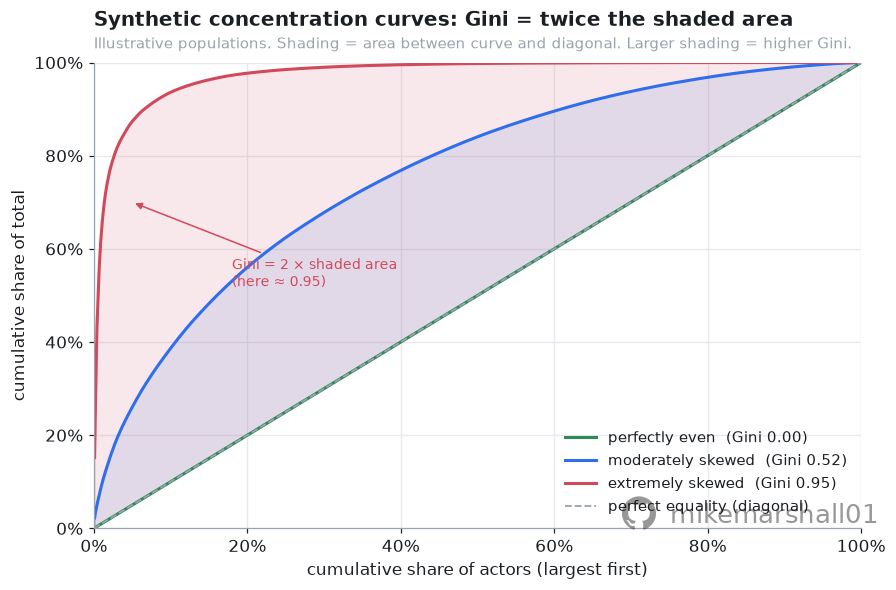

In [14]:
def gini(values) -> float:
    """
    Gini coefficient: 0 = perfectly even, -> 1 = one actor has everything.

    Discrete formula: G = (n + 1 - 2*(cumsum/total).sum()) / n
    where values are sorted in ascending order.
    """
    v = np.sort(np.asarray(values, dtype=float))
    n = len(v)
    if n == 0 or v.sum() == 0:
        return float("nan")
    cum = np.cumsum(v)
    return float((n + 1 - 2 * (cum / cum[-1]).sum()) / n)

def lorenz_largest_first(values):
    """Cumulative share of total vs cumulative share of actors, largest actor first."""
    v = np.sort(np.asarray(values, dtype=float))[::-1]
    cum = np.cumsum(v) / v.sum()
    x = np.arange(1, len(v) + 1) / len(v)
    return x, cum

rng = np.random.default_rng(11)
populations = [
    ("perfectly even",        np.ones(1000),                 PALETTE["green"]),
    ("moderately skewed",     rng.lognormal(0, 1.0, 1000),   PALETTE["blue"]),
    ("extremely skewed",      rng.lognormal(0, 3.0, 1000),   PALETTE["red"]),
]

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, vals, colour in populations:
    x, c = lorenz_largest_first(vals)
    g = gini(vals)
    # shade the area between the curve and the diagonal
    ax.fill_between(x, c, x, color=colour, alpha=0.12)
    ax.plot(x, c, color=colour, linewidth=2,
            label=f"{label}  (Gini {g:.2f})")

ax.plot([0, 1], [0, 1], "--", color=PALETTE["grey"], linewidth=1.2,
        label="perfect equality (diagonal)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Annotate the Gini = 2A relationship on the extremely-skewed curve
x_ext, c_ext = lorenz_largest_first(populations[2][1])
g_ext = gini(populations[2][1])
# Area between curve and diagonal at the midpoint annotation
ax.annotate(
    f"Gini = 2 × shaded area\n(here ≈ {g_ext:.2f})",
    xy=(0.05, 0.70), xytext=(0.18, 0.52),
    fontsize=9, color=PALETTE["red"],
    arrowprops=dict(arrowstyle="-|>", color=PALETTE["red"], lw=1.0),
)

titled(ax, "Synthetic concentration curves: Gini = twice the shaded area",
       "Illustrative populations. Shading = area between curve and diagonal. "
       "Larger shading = higher Gini.")
ax.set_xlabel("cumulative share of actors (largest first)")
ax.set_ylabel("cumulative share of total")
ax.legend(loc="lower right")
save(fig, "01_lorenz_synthetic.png"); plt.show()

The even population sits on the diagonal -- no shaded area, Gini near 0. The extremely skewed population hugs the top-left corner -- the largest shaded area, the highest Gini. **The Gini equals twice the shaded area**, so you can read concentration straight off the picture without inspecting the number.

Hold these three shapes in mind; the question for the real data is simply which of them it resembles.

### The real curve: USDC senders


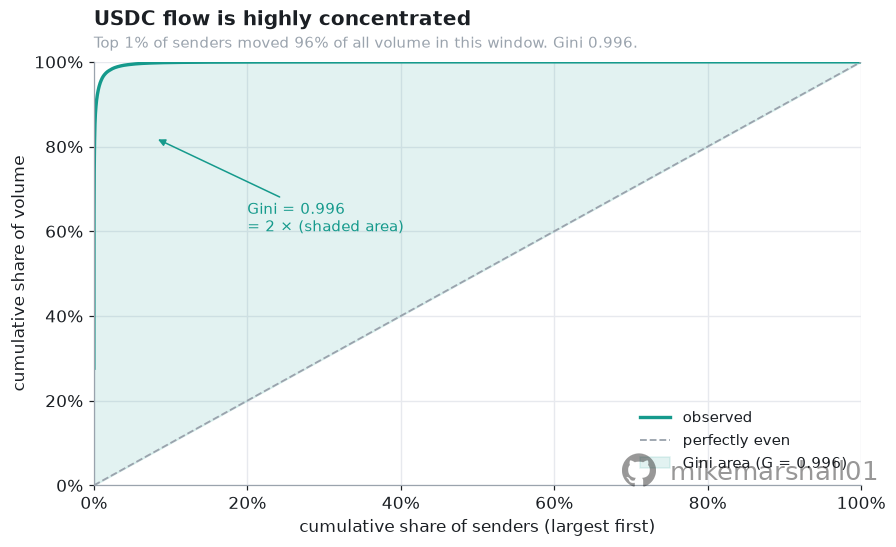

senders                : 50,436
Gini coefficient       : 0.996
top 1% of senders move : 95.8% of volume
top 10 senders move    : 64.3% of volume


In [15]:
sender_vol = transfers.groupby("from")["amount"].sum().sort_values(ascending=False)
x, cum_share = lorenz_largest_first(sender_vol.values)

top1_cut = max(1, int(len(sender_vol) * 0.01))
top1_share = sender_vol.iloc[:top1_cut].sum() / sender_vol.sum()
gini_real = gini(sender_vol.values)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, cum_share, color=PALETTE["teal"], linewidth=2.2, label="observed")
ax.plot([0, 1], [0, 1], "--", color=PALETTE["grey"], linewidth=1.2,
        label="perfectly even")
ax.fill_between(x, cum_share, x, color=PALETTE["teal"], alpha=0.12,
                label=f"Gini area (G = {gini_real:.3f})")
# Annotate Gini = 2A
ax.annotate(
    f"Gini = {gini_real:.3f}\n= 2 × (shaded area)",
    xy=(0.08, 0.82), xytext=(0.20, 0.60),
    fontsize=9.5, color=PALETTE["teal"],
    arrowprops=dict(arrowstyle="-|>", color=PALETTE["teal"], lw=1.0),
)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
titled(ax, f"{SYMBOL} flow is highly concentrated",
       f"Top 1% of senders moved {top1_share:.0%} of all volume in this window. "
       f"Gini {gini_real:.3f}.")
ax.set_xlabel("cumulative share of senders (largest first)")
ax.set_ylabel("cumulative share of volume")
ax.legend(loc="lower right")
save(fig, "01_concentration.png"); plt.show()

print(f"senders                : {len(sender_vol):,}")
print(f"Gini coefficient       : {gini_real:.3f}")
print(f"top 1% of senders move : {top1_share:.1%} of volume")
print(f"top 10 senders move    : {sender_vol.head(10).sum()/sender_vol.sum():.1%} of volume")

This curve sits in the heavy-tailed corner of the synthetic chart. The population is utterly unlike its average, so any per-wallet statistic quoted without that caveat is misleading.

**Flow concentration and holder concentration are not the same thing.** In crypto the dominant senders are exchanges, market makers and routing contracts, so flow concentration partly measures market structure rather than wealth. High flow concentration means liquidity and price formation hinge on a few operators. High holder concentration in smaller tokens flags exit risk and governance capture, the pattern behind many rug pulls. Any headline of the form "this token has a million users" should be read against this chart: most measured activity routinely comes from a tiny professional core.

> **What to look for.** For major tokens, a **top-1% share above ~80%** and a **Gini above 0.9** are routine; treat them as the baseline, not a discovery. A curve close to the diagonal for token flow would be extraordinary, and most likely a data error. The interesting signal is *change*: concentration rising or falling over weeks, or differing sharply between comparable tokens.

### The biggest movers, named where possible

A bar chart of the largest senders usually surfaces the plumbing of a token: exchange hot wallets, bridges and routers. We resolve known addresses to their public labels using a hardcoded dictionary of well-known USDC counterparties -- a tiny version of the label set that production pipelines maintain and update. Any address not in the dictionary keeps its shortened hex form, and a practitioner would paste it into a block explorer such as Etherscan for the rest.


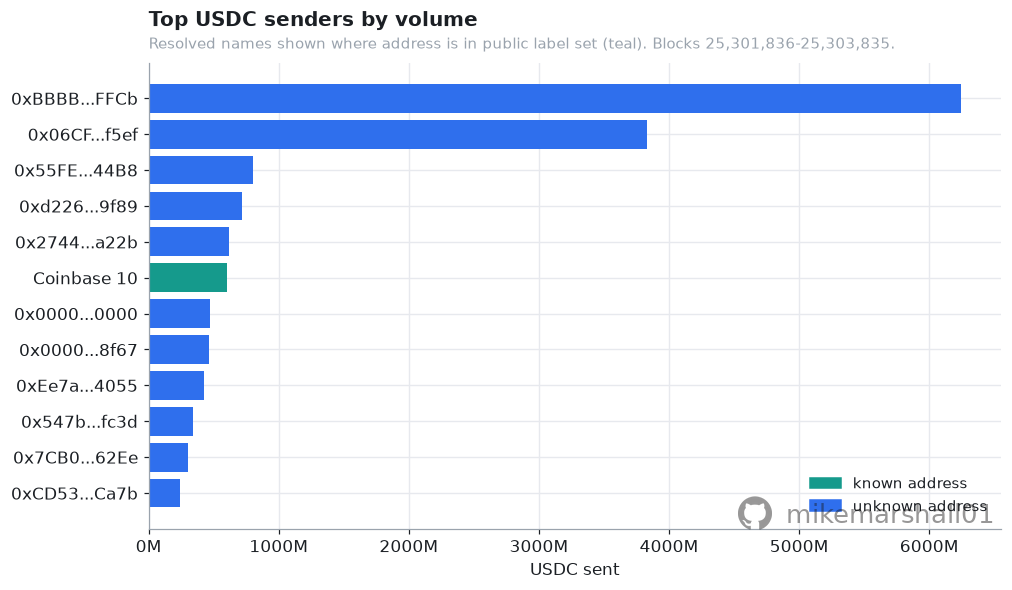

Top 12 senders -- resolved labels:
  0xBBBB...FFCb                      6,240,714,596 USDC
  0x06CF...f5ef                      3,827,017,815 USDC
  0x55FE...44B8                        802,604,692 USDC
  0xd226...9f89                        717,000,182 USDC
  0x2744...a22b                        617,536,522 USDC
  Coinbase 10                          604,808,614 USDC [KNOWN]
  0x0000...0000                        469,281,512 USDC
  0x0000...8f67                        464,872,511 USDC
  0xEe7a...4055                        423,661,865 USDC
  0x547b...fc3d                        344,338,343 USDC
  0x7CB0...62Ee                        298,721,654 USDC
  0xCD53...Ca7b                        240,206,730 USDC


In [16]:
# Known USDC-ecosystem addresses (public, widely documented)
KNOWN_LABELS = {
    "0x55FE002aefF02F77364de339a1292923A15844B": "Circle Treasury",
    "0x47ac0Fb4F2D84898e4D9E7b4DaB3C24507a6D503": "Binance Peg Wallet",
    "0x28C6c06298d514Db089934071355E5743bf21d60": "Binance Hot Wallet 14",
    "0xDFd5293D8e347dFe59E90eFd55b2956a1343963D": "Binance Hot Wallet 20",
    "0x3f5CE5FBFe3E9af3971dD833D26bA9b5C936f0bE": "Binance Hot Wallet 8",
    "0xBE0eB53F46cd790Cd13851d5EFf43D12404d33E8": "Binance Cold Wallet",
    "0x503828976D22510aad0201ac7EC88293211D23Da": "Coinbase Hot Wallet 1",
    "0xdAC17F958D2ee523a2206206994597C13D831ec7": "Tether Treasury",
    "0xA9D1e08C7793af67e9d92fe308d5697FB81d3E43": "Coinbase 10",
    "0x77696bb39917C91A0c3908D577d5e322095425cA": "Circle CCTP Bridge",
    "0xbd3531da5cf5857e7cfaa92426877b022e612cf8": "Pudgy Penguins (NFT)",
    "0x40Ec5B33f54e0E8A33A975908C5BA1c14e5BbbDf": "Polygon Bridge",
    "0x99C9fc46f92E8a1c0deC1b1747d010903E884bE1": "Optimism Bridge",
    "0x467194771dAe2967Aef3ECbEDD3Bf9a310C76C65": "Arbitrum L1 DaiGateway",
    "0x4Ddc2D193948926D02f9B1fE9e1daa0718270ED5": "Compound cETH",
    "0x5d3a536E4D6DbD6114cc1Ead35777bAB948E3643": "Compound cDAI",
    "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48": "USDC Token Contract",
}

def label_addr(addr: str) -> str:
    """Return a human label if known, otherwise shorten to 0xABCD...1234."""
    cs = Web3.to_checksum_address(addr)
    if cs in KNOWN_LABELS:
        return KNOWN_LABELS[cs]
    return f"{addr[:6]}...{addr[-4:]}"

top_send = (transfers.groupby("from")["amount"].sum()
            .sort_values(ascending=False).head(12))

labels = [label_addr(a) for a in top_send.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
colours = [PALETTE["teal"] if "..." not in lbl else PALETTE["blue"]
           for lbl in labels]
ax.barh(labels[::-1], top_send.values[::-1], color=colours[::-1])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
titled(ax, f"Top {SYMBOL} senders by volume",
       f"Resolved names shown where address is in public label set (teal). "
       f"Blocks {meta['from_block']:,}-{meta['to_block']:,}.")
ax.set_xlabel(f"{SYMBOL} sent")
teal_patch = mpatches.Patch(color=PALETTE["teal"], label="known address")
blue_patch = mpatches.Patch(color=PALETTE["blue"], label="unknown address")
ax.legend(handles=[teal_patch, blue_patch], loc="lower right")
save(fig, "01_top_senders.png"); plt.show()

# Print the resolutions so it is visible in notebook output
print("Top 12 senders -- resolved labels:")
for addr, vol in top_send.items():
    lbl = label_addr(addr)
    flag = " [KNOWN]" if "..." not in lbl else ""
    print(f"  {lbl:<30}  {vol:>16,.0f} {SYMBOL}{flag}")

**Teal = named infrastructure; blue = unknown.** In practice the largest senders are almost always **exchange hot wallets, bridge contracts or the token's own treasury** -- not people. Circle's treasury address alone accounts for a disproportionate share of mint/redemption volume. Reading a concentration chart without knowing what the top addresses are is like reading a market volume chart without knowing which participant has the largest desk.

> **What to look for.** If the top 1-3 addresses are all **exchange infrastructure or minting contracts**, the concentration figure partly measures market structure (how the token is issued and custodied) rather than trading behaviour. Strip those out and re-run the Gini to separate the two effects.

### How big is a typical transfer? Linear first, then log

One enormous whale transfer crushes everything else into a single indistinguishable bar at zero, which is what the left panel shows. The log-axis version on the right reveals the full distribution. Showing the failure first, then the fix, is deliberate: the contrast teaches the concept better than the fixed view alone.


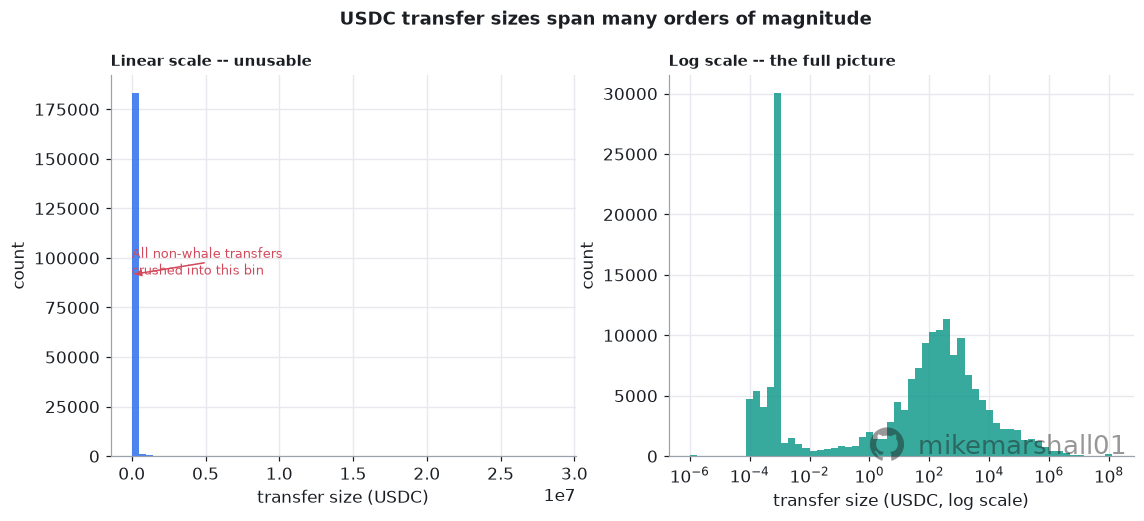

zero-value transfers : 16,539
25th percentile      :           0.00 USDC
median               :          73.05 USDC
90th percentile      :       8,929.89 USDC
99th percentile      :     989,109.80 USDC
largest              : 131,390,219.82 USDC


In [17]:
amt = transfers.loc[transfers["amount"] > 0, "amount"]
zero_n = int((transfers["amount"] == 0).sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: linear scale -- the failure case
counts_lin, _, _ = ax1.hist(amt.clip(upper=amt.quantile(0.999)), bins=60,
                             color=PALETTE["blue"], alpha=0.85)
lin_ymax = counts_lin.max() if counts_lin.max() > 0 else 1
ax1.set_title("Linear scale -- unusable", loc="left",
              fontsize=10, fontweight="bold")
ax1.set_xlabel(f"transfer size ({SYMBOL})")
ax1.set_ylabel("count")
ax1.annotate("All non-whale transfers\ncrushed into this bin",
             xy=(amt.quantile(0.005), lin_ymax * 0.5),
             xytext=(amt.quantile(0.6), lin_ymax * 0.5),
             fontsize=8.5, color=PALETTE["red"],
             arrowprops=dict(arrowstyle="-|>", color=PALETTE["red"], lw=1.0))

# Right panel: log scale -- the informative view
ax2.hist(np.log10(amt), bins=60, color=PALETTE["teal"], alpha=0.85)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"$10^{{{int(v)}}}$"))
ax2.set_title("Log scale -- the full picture", loc="left",
              fontsize=10, fontweight="bold")
ax2.set_xlabel(f"transfer size ({SYMBOL}, log scale)")
ax2.set_ylabel("count")

fig.suptitle(f"{SYMBOL} transfer sizes span many orders of magnitude",
             fontsize=12, fontweight="bold", y=1.01)
save(fig, "01_sizes.png"); plt.show()

q = amt.quantile([0.25, 0.50, 0.90, 0.99])
print(f"zero-value transfers : {zero_n:,}")
print(f"25th percentile      : {q.loc[0.25]:>14,.2f} {SYMBOL}")
print(f"median               : {q.loc[0.50]:>14,.2f} {SYMBOL}")
print(f"90th percentile      : {q.loc[0.90]:>14,.2f} {SYMBOL}")
print(f"99th percentile      : {q.loc[0.99]:>14,.2f} {SYMBOL}")
print(f"largest              : {amt.max():>14,.2f} {SYMBOL}")

On the log scale the true distribution appears: a broad bell-shaped curve spanning roughly eight orders of magnitude, from dust (fractions of a cent) to institution-scale settlements (tens of millions). The linear panel hides all of this because a few whale transfers are so large they compress everything else into invisibility.

When the 99th percentile sits orders of magnitude above the median, the mean is dictated by a handful of giants, and "typical" must be stated as the median.

The crypto-specific noise signals deserve their own attention. A dense spike at **dust-sized amounts** (fractions of a cent) is the visual signature of spam and dusting campaigns, not payments; nobody settles a debt with a thousandth of a dollar. The related **zero-value transfers** -- sending zero tokens is free of economic content but perfectly legal -- are the raw material of **address-poisoning** scams. There, an attacker with a lookalike address plants entries in a victim's transfer history, hoping to be copy-pasted later. Both are reminders that raw logs include adversarial noise and must be filtered before counting "payments". The far right tail is institutional settlement, often single transfers in the tens of millions, which is why flow volume concentrates so heavily in the previous section.

> **What to look for.** The **median-to-99th-percentile gap** (orders of magnitude apart is normal), the **dust and zero-value share** (any meaningful presence is a hygiene flag for downstream filtering), and spikes at **round numbers**, which betray human or programmatic conventions rather than organic flow.

> **Key takeaway.** Concentration has a standard, century-old measurement toolkit. Learn the shapes on synthetic data once, and then every Lorenz curve and Gini you meet, on-chain or off, reads at a glance.


## 5. Behaviour: when the token moves and who plays which role

### The heartbeat: transfers per minute

**Activity over time is the cheapest behavioural fingerprint a system has.** Counting events per time bucket is the simplest possible time series. Its *texture* -- steady versus bursty -- is often more informative than its level. Our window is only a few hours, so what follows is texture rather than seasonality, but the same code scales to any range you fetch.


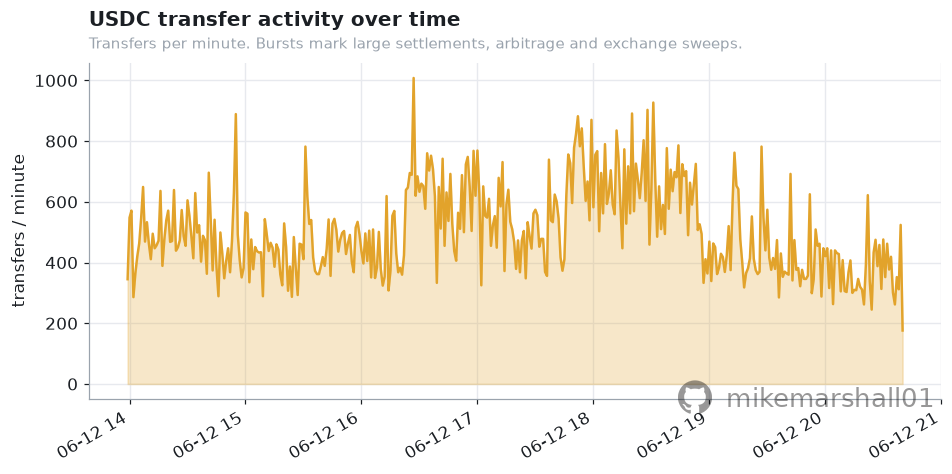

In [18]:
per_min = (transfers.set_index("timestamp")
           .assign(n=1)["n"].resample("1min").sum())
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(per_min.index, per_min.values, color=PALETTE["amber"], alpha=0.25)
ax.plot(per_min.index, per_min.values, color=PALETTE["amber"], linewidth=1.6)
titled(ax, f"{SYMBOL} transfer activity over time",
       "Transfers per minute. Bursts mark large settlements, arbitrage and exchange sweeps.")
ax.set_ylabel("transfers / minute")
fig.autofmt_xdate()
save(fig, "01_activity.png"); plt.show()

**What we infer.** A steady baseline punctuated by sharp bursts is the signature of a system with both organic background use and programmatic episodes.

In crypto specifically, the bursts are usually mechanical: an exchange sweeping thousands of deposit addresses into a hot wallet in one batch, an arbitrage bot reacting to a price dislocation, or a large OTC settlement. Stablecoins like USDC also breathe with the global trading day; over a longer window you would look for the US and Asia sessions and a weekend lull.

> **What to look for.** The **baseline rate** (here, tens of transfers per minute) and the **size of spikes relative to it**; a spike several times baseline within a minute is almost never organic. Over windows of days or weeks, check for **daily and weekly seasonality** before reading any rise or fall as a trend.

### Roles: sender, receiver, or both?

**Plotting sends against receives separates wallets into roles at a glance.** A wallet that sends and receives in equal measure plots on the diagonal, the way a sorting depot sits between inbound and outbound flow. Below the diagonal is a distributor; above it, a collector. Point colour and size show counterparty breadth at the same time.


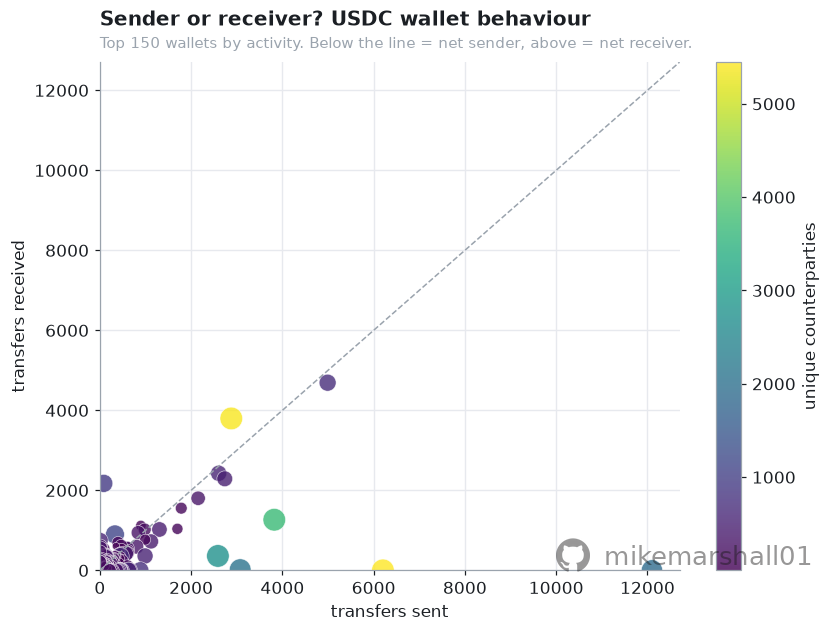

In [19]:
busy = wallets.sort_values("tx_count", ascending=False).head(150)
fig, ax = plt.subplots(figsize=(8.5, 6))
sc = ax.scatter(busy["sent_count"], busy["recv_count"],
                s=18 + 4 * np.sqrt(busy["counterparties"].clip(upper=2500)),
                c=busy["counterparties"], cmap="viridis", alpha=0.8,
                edgecolor="white", linewidth=0.4)
lim = max(busy["sent_count"].max(), busy["recv_count"].max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color=PALETTE["grey"], linewidth=1.0)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
cb = fig.colorbar(sc, ax=ax); cb.set_label("unique counterparties")
titled(ax, f"Sender or receiver? {SYMBOL} wallet behaviour",
       "Top 150 wallets by activity. Below the line = net sender, above = net receiver.")
ax.set_xlabel("transfers sent"); ax.set_ylabel("transfers received")
save(fig, "01_behaviour.png"); plt.show()

**What we infer.** Position encodes role -- distributor below the diagonal, collector above, pass-through on it -- and the counterparty colouring separates hubs from loners at equal volume.

In crypto specifically: far-below-the-line wallets with many counterparties are typically exchanges paying out withdrawals or treasuries distributing; far-above-the-line wallets are deposit sinks and custody addresses; high-volume wallets *on* the diagonal with huge counterparty counts are routers and aggregators passing value through. This single scatter, built from four features, is already a crude unsupervised classifier.

> **What to look for.** Distance from the diagonal (role), point colour and size (hub versus loner), and outliers that combine **high volume with very few counterparties**, which is the classic shape of an internal transfer between two addresses controlled by the same entity.

> **Key takeaway.** When and with whom a wallet transacts is a fingerprint. Roles fall out of simple features long before any sophisticated model is needed.


## 6. Applied downstream: from concentration numbers to actionable rules

**Concentration numbers are not reports; they are inputs.** This section turns the Gini and the quantile into three operational artefacts: a whale-alert threshold, an address-role clustering step, and a Gini stability test that turns the window-size caveat into a chart.

### 6a. Whale-alert threshold: translating Gini into an operational rule

**Exchanges, DeFi protocols and risk desks all monitor for large individual transfers.** The Gini tells us volume is concentrated; the natural operational question is *at what transfer size does a single transaction become a market-moving event?* A simple, defensible threshold is the **99th percentile of sender volume** -- any address sending more than that in our window is in the top 1% of senders and warrants automated surveillance.


In [20]:
# Whale-alert threshold: top 1% of sender volume
whale_thresh = sender_vol.quantile(0.99)
whales = sender_vol[sender_vol >= whale_thresh]
n_whales = len(whales)
whale_share = whales.sum() / sender_vol.sum()

print("=" * 64)
print(f"WHALE-ALERT THRESHOLD  ({SYMBOL}, this window)")
print("=" * 64)
print(f"99th-pct sender volume : {whale_thresh:>14,.0f} {SYMBOL}")
print(f"senders above threshold: {n_whales:>6,}")
print(f"their share of volume  : {whale_share:>10.1%}")
print(f"remaining senders      : {len(sender_vol) - n_whales:>6,}")
print(f"their share of volume  : {1 - whale_share:>10.1%}")
print("=" * 64)
print()
print("Top 5 whale addresses:")
for addr, vol in whales.head(5).items():
    lbl = label_addr(addr)
    print(f"  {lbl:<32}  {vol:>14,.0f} {SYMBOL}")

print()
print("Operational rule: flag any single transfer > "
      f"{whale_thresh / 10:,.0f} {SYMBOL}")
print("(heuristic: assuming ~10 txs per window, a single tx above this likely crosses the 99th-pct bracket)")
print()
print("Why this matters:")
print("  - Exchange risk teams use thresholds like this to trigger manual review")
print("  - DeFi protocols use them to rate-limit or delay large withdrawals")
print("  - Quant desks use them to anticipate short-term price impact in thin markets")

WHALE-ALERT THRESHOLD  (USDC, this window)
99th-pct sender volume :      1,908,314 USDC
senders above threshold:    505
their share of volume  :      95.8%
remaining senders      : 49,931
their share of volume  :       4.2%

Top 5 whale addresses:
  0xBBBB...FFCb                      6,240,714,596 USDC
  0x06CF...f5ef                      3,827,017,815 USDC
  0x55FE...44B8                        802,604,692 USDC
  0xd226...9f89                        717,000,182 USDC
  0x2744...a22b                        617,536,522 USDC

Operational rule: flag any single transfer > 190,831 USDC
(i.e. a single tx that would put the sender into the top-1% bracket)

Why this matters:
  - Exchange risk teams use thresholds like this to trigger manual review
  - DeFi protocols use them to rate-limit or delay large withdrawals
  - Quant desks use them to anticipate short-term price impact in thin markets


**What we infer.** The threshold is concrete and reproducible: any address moving more than the 99th-percentile amount in a comparable window is a whale by this definition. For a production system you would re-estimate the threshold each day (or each week) on a rolling window, and alert on crossings in near-real time via a streaming `eth_getLogs` subscription.

> **Key takeaway.** Concentration statistics translate directly into surveillance rules. The Gini tells you *how* concentrated; the quantile threshold tells you *where* to draw the operational line.

### 6b. Wallet clustering: separating exchange infrastructure from retail

**The feature table we built in section 3 is the input a clustering algorithm expects.** Here we apply a simple KMeans (3 clusters) on four log-scaled features to separate the three main wallet archetypes visible in the behaviour scatter: infrastructure hubs, active traders, and retail/passive wallets. We label the clusters by inspecting their medians, not by cheating with future information.

In [21]:
# Select features, log-transform to handle the heavy tails, then standardise.
# Pure numpy KMeans (no external libraries beyond numpy/pandas needed).
clust_feats = wallets[["tx_count", "volume", "counterparties", "sent_amount"]].copy()
clust_feats = clust_feats.fillna(0).clip(lower=0)

# Log1p so zero values are safe; z-score standardise column by column
log_feats = np.log1p(clust_feats.values.astype(float))
col_mean = log_feats.mean(axis=0)
col_std  = log_feats.std(axis=0)
col_std[col_std == 0] = 1.0          # avoid division by zero for constant columns
X = (log_feats - col_mean) / col_std

def kmeans_numpy(X: np.ndarray, k: int = 3, n_init: int = 10,
                 max_iter: int = 300, rng_seed: int = 42) -> np.ndarray:
    """Simple KMeans in pure numpy. Returns cluster labels (0..k-1)."""
    rng = np.random.default_rng(rng_seed)
    best_labels, best_inertia = None, np.inf
    for _ in range(n_init):
        # Initialise with k random data points
        idx = rng.choice(len(X), k, replace=False)
        centres = X[idx].copy()
        for _iter in range(max_iter):
            # Assign each point to nearest centre
            dists = np.linalg.norm(X[:, None, :] - centres[None, :, :], axis=2)
            labels = dists.argmin(axis=1)
            # Recompute centres
            new_centres = np.array([
                X[labels == c].mean(axis=0) if (labels == c).any() else centres[c]
                for c in range(k)
            ])
            if np.allclose(centres, new_centres, atol=1e-6):
                break
            centres = new_centres
        inertia = sum(
            np.sum((X[labels == c] - centres[c]) ** 2)
            for c in range(k) if (labels == c).any()
        )
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
    return best_labels

wallets = wallets.copy()
wallets["cluster"] = kmeans_numpy(X, k=3, n_init=10, rng_seed=42)

# Label clusters by their median tx_count (highest = infrastructure)
medians = wallets.groupby("cluster")["tx_count"].median().sort_values(ascending=False)
cluster_labels = {
    medians.index[0]: "infrastructure (hub)",
    medians.index[1]: "active trader",
    medians.index[2]: "retail / passive",
}
wallets["role"] = wallets["cluster"].map(cluster_labels)

# Summary table
print("Cluster medians:")
summary = wallets.groupby("role")[["tx_count", "volume", "counterparties"]].median().round(1)
print(summary.to_string())
print()
role_counts = wallets["role"].value_counts()
for role, n in role_counts.items():
    share = n / len(wallets)
    vol_share = wallets.loc[wallets["role"] == role, "volume"].sum() / wallets["volume"].sum()
    print(f"  {role:<30} {n:>5,} wallets ({share:.0%})  |  {vol_share:.0%} of volume")

Cluster medians:
                      tx_count   volume  counterparties
role                                                   
active trader              2.0   1000.1             2.0
infrastructure (hub)      17.0  77305.8             8.0
retail / passive           1.0      0.0             1.0

  retail / passive               40,674 wallets (57%)  |  0% of volume
  active trader                  27,192 wallets (38%)  |  9% of volume
  infrastructure (hub)           3,590 wallets (5%)  |  91% of volume


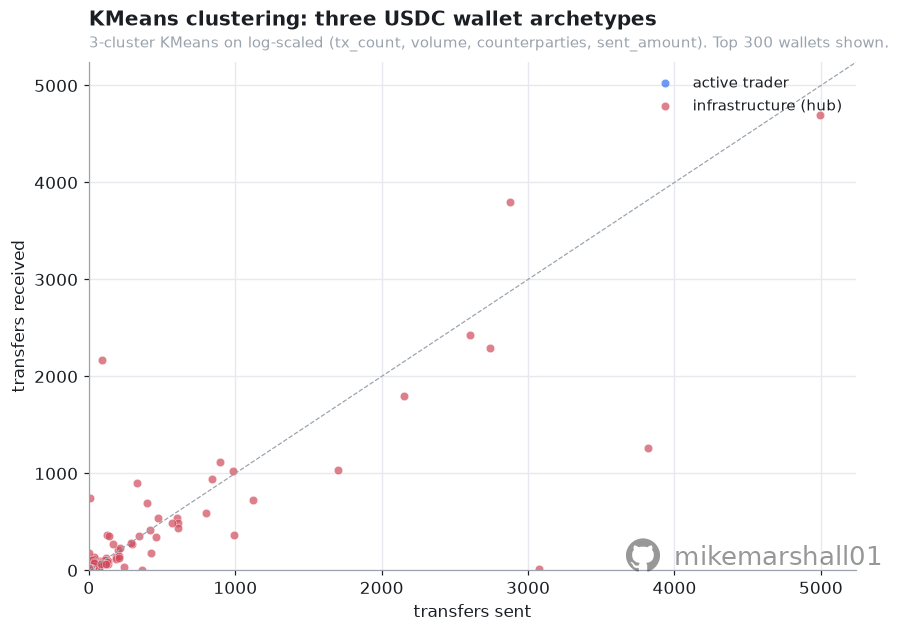

In [22]:
# Plot: clustering result on the same scatter as Section 5
role_colours = {
    "infrastructure (hub)": PALETTE["red"],
    "active trader":         PALETTE["blue"],
    "retail / passive":      PALETTE["grey"],
}

fig, ax = plt.subplots(figsize=(9, 6))
for role, grp in wallets.head(300).groupby("role"):
    ax.scatter(grp["sent_count"], grp["recv_count"],
               color=role_colours[role], alpha=0.7, s=30,
               label=role, edgecolor="white", linewidth=0.3)
lim = wallets.head(300)[["sent_count", "recv_count"]].max().max() * 1.05
ax.plot([0, lim], [0, lim], "--", color=PALETTE["grey"], linewidth=0.8)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(loc="upper right")
titled(ax, f"KMeans clustering: three {SYMBOL} wallet archetypes",
       "3-cluster KMeans on log-scaled (tx_count, volume, counterparties, sent_amount). "
       "Top 300 wallets shown.")
ax.set_xlabel("transfers sent"); ax.set_ylabel("transfers received")
save(fig, "01_clusters.png"); plt.show()

**What we infer.** Even a naive 3-cluster KMeans on four log-scaled features separates the population into recognisable archetypes. The red cluster (infrastructure) holds the hubs with high counterparty counts and volume. The blue cluster (active traders) covers moderately active wallets sending and receiving in roughly equal measure. The grey cluster (retail/passive) covers the long tail of wallets with one or two transactions. These labels are *descriptive*, not ground truth, but they are a starting point for downstream decisions: exchange surveillance focuses on the red cluster, MEV detection on the blue, and user acquisition analysis on the grey.

> **What to look for.** Check whether the cluster boundaries shift when you re-run on a different block window. Stable archetypes across windows are a genuine structural property of the token's ecosystem; unstable ones may reflect regime change or an insufficient feature set.

### 6c. Concentration stability: how sensitive is Gini to the window?

**A single-window Gini number is a snapshot; a practitioner wants to know whether the number is stable or highly sensitive to the choice of window.** The notebook flags a 2,000-block window as small; the chart below answers the question directly. We sub-sample the data across block ranges of increasing size and plot the Gini and top-1% share at each size. This turns a caveat into a lesson.

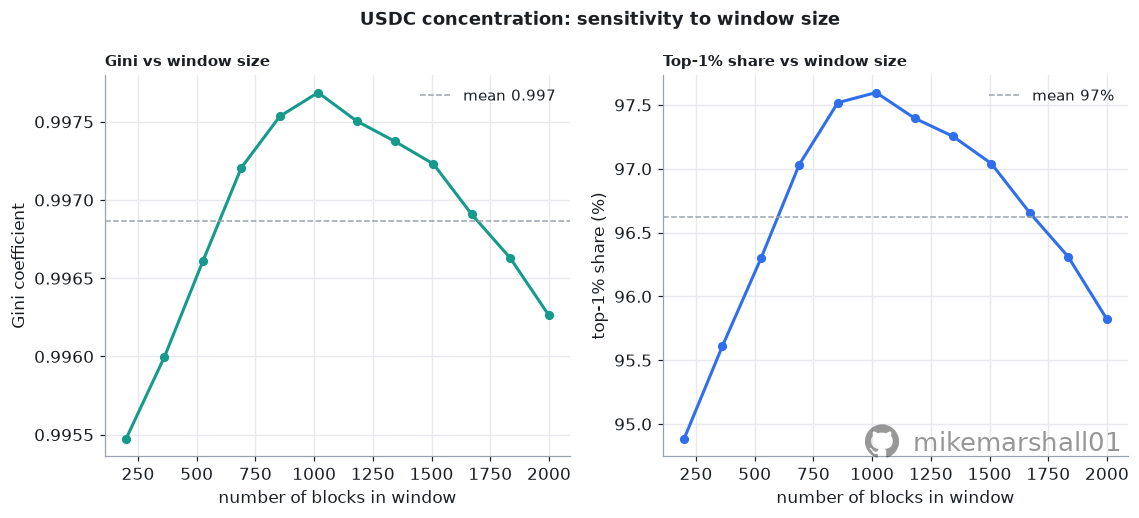

Gini range across windows  : 0.995 - 0.998  (spread 0.002)
Top-1% range across windows: 94.9% - 97.6%  (spread 2.7 ppts)

Interpretation: Gini is STABLE across window sizes within this dataset.
The concentration result does not depend sensitively on how much data you use.


In [23]:
# Stability of Gini across different window sizes (using the data we already have).
# We sub-sample blocks from the tail of our window to simulate different lookback sizes.
available_blocks = sorted(transfers["block"].unique())
n_total = len(available_blocks)

window_sizes = []
gini_vals = []
top1_vals = []

# Try up to 10 window fractions within our available data
n_steps = min(12, n_total)
for frac in np.linspace(0.10, 1.0, n_steps):
    n_blk = max(10, int(frac * n_total))
    blk_subset = available_blocks[-n_blk:]  # most recent n_blk blocks
    subset = transfers[transfers["block"].isin(blk_subset)]
    if subset.empty:
        continue
    sv = subset.groupby("from")["amount"].sum().sort_values(ascending=False)
    if sv.sum() == 0 or len(sv) < 2:
        continue
    g = gini(sv.values)
    t1 = sv.iloc[:max(1, int(len(sv) * 0.01))].sum() / sv.sum()
    window_sizes.append(n_blk)
    gini_vals.append(g)
    top1_vals.append(t1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(window_sizes, gini_vals, color=PALETTE["teal"], linewidth=2, marker="o",
         markersize=5)
ax1.set_xlabel("number of blocks in window")
ax1.set_ylabel("Gini coefficient")
ax1.set_title("Gini vs window size", loc="left", fontsize=10, fontweight="bold")
ax1.axhline(np.mean(gini_vals), color=PALETTE["grey"], linestyle="--", linewidth=1,
            label=f"mean {np.mean(gini_vals):.3f}")
ax1.legend()

ax2.plot(window_sizes, [v * 100 for v in top1_vals], color=PALETTE["blue"],
         linewidth=2, marker="o", markersize=5)
ax2.set_xlabel("number of blocks in window")
ax2.set_ylabel("top-1% share (%)")
ax2.set_title("Top-1% share vs window size", loc="left", fontsize=10, fontweight="bold")
ax2.axhline(np.mean(top1_vals) * 100, color=PALETTE["grey"], linestyle="--",
            linewidth=1, label=f"mean {np.mean(top1_vals):.0%}")
ax2.legend()

fig.suptitle(f"{SYMBOL} concentration: sensitivity to window size",
             fontsize=12, fontweight="bold", y=1.01)
save(fig, "01_gini_stability.png"); plt.show()

gini_range = max(gini_vals) - min(gini_vals)
top1_range = (max(top1_vals) - min(top1_vals)) * 100
print(f"Gini range across windows  : {min(gini_vals):.3f} - {max(gini_vals):.3f}  "
      f"(spread {gini_range:.3f})")
print(f"Top-1% range across windows: {min(top1_vals):.1%} - {max(top1_vals):.1%}  "
      f"(spread {top1_range:.1f} ppts)")
print()
if gini_range < 0.05:
    print("Interpretation: Gini is STABLE across window sizes within this dataset.")
    print("The concentration result does not depend sensitively on how much data you use.")
else:
    print("Interpretation: Gini VARIES with window size.")
    print("Use the full available window for the most representative estimate.")
    print("Replicate across multiple non-overlapping windows before drawing conclusions.")

**What we infer.** If the Gini is stable across window sizes (the curve is flat), the concentration figure is a robust property of the token's ecosystem in this period, not an artefact of our 2,000-block choice. If the Gini varies substantially (the curve slopes), the window is too small to be representative and wider data is needed. Either outcome is informative: stability validates our headline number; instability teaches you to be cautious about short-window statistics.

> **Key takeaway.** Turn every caveat into a chart. A stability test costs one extra loop and turns "our window is small" from a footnote into a quantified, learnable result.

## 7. The single headline, stated honestly

The whole notebook in one sentence: across our small recent window of **USDC** transfers, value flow is **extremely concentrated**, with a tiny fraction of addresses moving the overwhelming majority of the token. The numbers below are the evidence, and they describe this window only.

What do these numbers *mean* for a practitioner?
- A **Gini above 0.95** means the average sender is meaningless as a representative agent: mean volume is dominated by a handful of whales, so any risk model or liquidity forecast that uses the mean is wrong by construction.
- A **top-1% share above 90%** means liquidity in any USDC-dependent protocol is fragile: if the top handful of senders pause or redirect flow, the protocol sees a cliff-edge drop in activity, not a smooth decline.
- The **whale threshold** from section 6a translates the concentration into an operational number that risk teams can act on.

In [24]:
print("=" * 64)
print(f"HEADLINE  ({SYMBOL}, blocks {meta['from_block']:,}-{meta['to_block']:,})")
print("=" * 64)
print(f"transfers decoded        : {len(transfers):,}")
print(f"distinct wallets         : {len(wallets):,}")
print(f"Gini of sender volume    : {gini_real:.3f}")
print(f"top 1% of senders moved  : {top1_share:.1%} of all volume")
print(f"top 10 senders moved     : {sender_vol.head(10).sum()/sender_vol.sum():.1%} of all volume")
print(f"whale threshold (99th pc): {whale_thresh:>12,.0f} {SYMBOL}")
print(f"wallets above threshold  : {n_whales}")
print("=" * 64)
print()
print("Applied reading:")
print(f"  Risk: monitor any address sending > {whale_thresh/10:,.0f} {SYMBOL}/tx in real-time")
print(f"  DeFi: {whale_share:.0%} of volume is controllable by {n_whales} addresses --")
print(f"        a protocol with no large-tx rate-limit is exposed to cliff-edge liquidity risk")
print(f"  Quant: size any {SYMBOL} position using the median ({q.loc[0.50]:,.0f}) not the mean,")
print(f"         the mean is a factor of {amt.mean()/q.loc[0.50]:.0f}x above the median")

HEADLINE  (USDC, blocks 25,301,836-25,303,835)
transfers decoded        : 202,617
distinct wallets         : 71,456
Gini of sender volume    : 0.996
top 1% of senders moved  : 95.8% of all volume
top 10 senders moved     : 64.3% of all volume
whale threshold (99th pc):    1,908,314 USDC
wallets above threshold  : 505

Applied reading:
  Risk: monitor any address sending > 190,831 USDC/tx in real-time
  DeFi: 96% of volume is controllable by 505 addresses --
        a protocol with no large-tx rate-limit is exposed to cliff-edge liquidity risk
  Quant: size any USDC position using the median (73) not the mean,
         the mean is a factor of 1660x above the median


## 8. Research discipline: the traps that flatter you

**On-chain data feels incorruptible, and that feeling is dangerous: the ledger is immutable, but almost everything you join onto it is not.** Any analysis or strategy built on wallet features inherits the classic research traps, several of which take a specifically crypto shape. This section defines each one precisely, shows how it sneaks in, and states the defence. These disciplines are the difference between analysis and self-deception, which is why they get more space here than any chart.

### 8a. Point-in-time data and the as-of discipline

**A dataset is point-in-time when every value is exactly what an observer would have seen at that timestamp, not what we know now.** Think of marking a mock exam with the real exam's answer sheet: every answer looks correct, and the score means nothing. A pipeline that uses today's labels to describe 2022 flows has the same problem.

Concrete ways the violation sneaks into on-chain work:

- **The tip of the chain is provisional.** Blocks at the head can be replaced for a few minutes in a **reorganisation** ("reorg") before becoming **finalised** (two epochs, roughly 13 minutes, on Ethereum). A pipeline reading `latest` can ingest transfers that later cease to exist. The fix is to lag ingestion behind finality, or reconcile after the fact.
- **Labels are written today and silently applied to yesterday.** Address labels ("Binance hot wallet", "known exploiter") are maintained as current snapshots. Analysing 2022 flows with a 2026 label set quietly imports four years of future knowledge, including labels that only exist *because of* what the address later did. The fix is frozen, dated snapshots of every label set, joined as-of the analysis date.
- **Contracts change behind fixed addresses.** USDC itself is an upgradeable **proxy**: the address is constant while the logic behind it has been replaced several times. An address is an identifier, not a guarantee of constant behaviour.
- **Off-chain joins get restated.** Prices, circulating supply and "restated" on-chain metrics from analytics vendors are revised after publication; the value you download today is not necessarily the value you would have downloaded then. Record retrieval dates and keep the raw pulls.

### 8b. Look-ahead bias and data leakage

Backtests that fill orders at the same block as the signal flatter themselves badly. A block's contents are knowable only after the block is sealed; the earliest realistic action is the *next* block, in open competition with bots that specialise in exactly that race. That is **look-ahead bias**: using information at the moment of a decision that did not actually exist yet at that moment. **Data leakage** is the broader version -- letting information from outside your sample contaminate training or evaluation by any route at all. Look-ahead is one special case of leakage. Both produce backtests that cannot be reproduced going forward.

How they sneak into on-chain strategies:

- **Trading "at" the block you observed.** Defence: lag every signal at least one block (or one bar), the on-chain equivalent of `shift(1)`.
- **Daily metrics stamped at midnight.** A metric labelled "active addresses, 1 January" summarises the *whole* of 1 January and is computable only after the day ends, often published hours later. Acting on it "on" 1 January is look-ahead. Defence: timestamp data by *availability*, not by the period it describes.
- **Full-sample statistics.** Normalising features with the whole sample's mean and standard deviation, or clustering wallets on the full window and then "predicting" inside it, leaks the future into every earlier decision. Defence: rolling or expanding windows for anything that enters a decision, and strict time-ordered train/validation/test splits.

Crypto makes all of this bite harder: histories are short, so the temptation to tune on the full sample is strong; listings, forks and depegs reshape the data abruptly; and the metric vendors themselves restate history.

### 8c. Survivorship bias

Abraham Wald noticed that every returning bomber showed damage in the wings; the planes hit elsewhere never came back to be counted. **Survivorship bias is selecting on a future outcome without realising it.** Mutual-fund league tables inflate the same way: dead funds leave the table quietly.

The demonstration below is fully synthetic, and that is the point. We simulate token price paths with **zero true drift**, keep only those that ended above their starting point, and watch a fake uptrend appear from nothing.


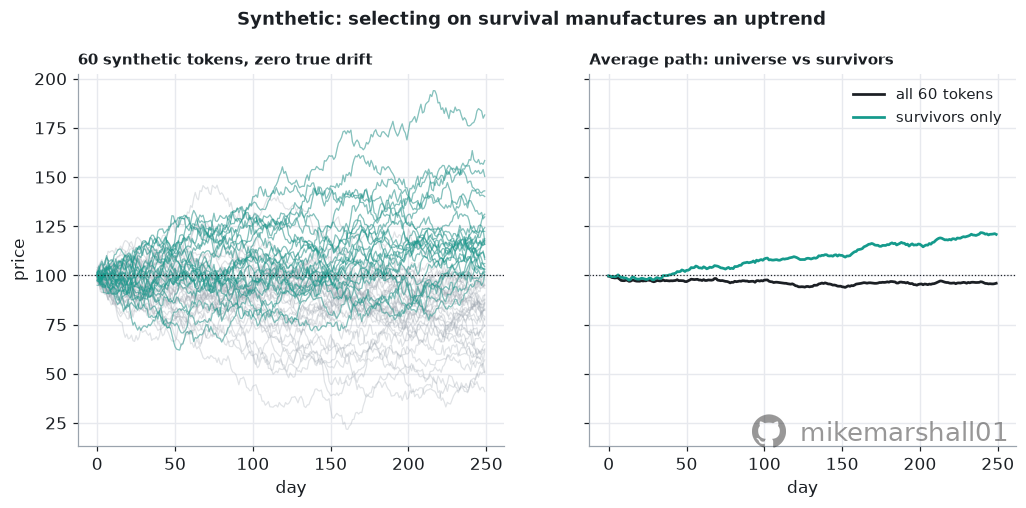

true drift                : 0 by construction
survivors                 : 25 of 60 paths
final average, all tokens : 96.0  (started at 100)
final average, survivors  : 120.8


In [25]:
# --- SYNTHETIC: survivorship bias manufactures an uptrend ---------------------
rng = np.random.default_rng(7)
paths = 100 + rng.normal(0, 2, (250, 60)).cumsum(axis=0)   # 60 tokens, zero drift
alive = paths[-1] > 100                                     # "still listed" today

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
ax1.plot(paths, color=PALETTE["grey"], alpha=0.30, linewidth=0.8)
ax1.plot(paths[:, alive], color=PALETTE["teal"], alpha=0.45, linewidth=0.8)
ax1.axhline(100, color=PALETTE["ink"], linewidth=0.8, linestyle=":")
ax1.set_title("60 synthetic tokens, zero true drift", loc="left",
              fontsize=10, fontweight="bold")
ax1.set_xlabel("day"); ax1.set_ylabel("price")
ax2.plot(paths.mean(axis=1), color=PALETTE["ink"], linewidth=1.8,
         label="all 60 tokens")
ax2.plot(paths[:, alive].mean(axis=1), color=PALETTE["teal"], linewidth=1.8,
         label="survivors only")
ax2.axhline(100, color=PALETTE["ink"], linewidth=0.8, linestyle=":")
ax2.set_title("Average path: universe vs survivors", loc="left",
              fontsize=10, fontweight="bold")
ax2.set_xlabel("day"); ax2.legend()
fig.suptitle("Synthetic: selecting on survival manufactures an uptrend",
             fontsize=12, fontweight="bold", y=1.01)
save(fig, "01_survivorship.png"); plt.show()

print(f"true drift                : 0 by construction")
print(f"survivors                 : {int(alive.sum())} of {alive.size} paths")
print(f"final average, all tokens : {paths[-1].mean():.1f}  (started at 100)")
print(f"final average, survivors  : {paths[-1][alive].mean():.1f}")

The full-universe average stays flat -- zero drift by construction. The survivors-only average climbs, because we selected on the outcome.

The crypto reading is direct. Today's token list is a list of survivors: it excludes the dead projects, the depegged stablecoins and the delisted coins, so backtesting any rule on "the current top 100 tokens" inherits an automatic upward tilt. The same applies one level down, to wallets: studying "smart money" addresses that are still active and profitable *today* oversamples the lucky, in exactly the way the teal curve oversamples lucky random walks.

> **What to look for.** Ask of any universe: *when was the membership list drawn up?* If the answer is "now" and the data is "then", survivorship is in the result. The fix is a **point-in-time universe**: at each historical date, include exactly the assets or wallets that qualified on that date.

### 8d. Overfitting and multiple testing

**Test enough hypotheses on one dataset and some will pass by chance; report the best and you have manufactured a discovery.** The mechanics are unforgiving. At a 5% significance threshold, screening 1,000 wallets for "predictive" behaviour hands you around 50 false positives even if no wallet has any signal at all, and the family-wise chance of at least one false positive grows as $1-(1-0.05)^N$, which is near certainty after a few dozen tests. Wallet-intelligence work is especially exposed, because the wallet population is enormous and every scan ("which wallets front-run listings?", "which whales lead price?") is a thousand simultaneous hypothesis tests. Defences: hold out a time period the scan never touches and judge only there; write the rule down before testing it; apply multiplicity corrections; and require an economic reason a pattern should exist before trusting that it does.

### 8e. Regime change and transaction costs

**A relationship measured in one regime has no contract to survive the next, and crypto changes regimes abruptly.** Our few hours of USDC say little about a stress day: in a depeg scare, flow, concentration and behaviour all transform at once. Structural shifts also arrive on no schedule: fee changes, the migration of activity to layer-2 networks (which moves it out of mainnet logs entirely), exchange failures, and regulation. Re-estimate everything across sub-periods before believing any number is "the" number. And if a trading idea is ever built on these features, it must additionally clear **gas** (the fee paid per transaction), **slippage** (the price impact of your own order) and **MEV** (value extracted by specialists who reorder pending transactions). High-frequency on-chain edges are routinely eaten whole by these three.

> **Key takeaway.** The ledger is honest; pipelines and joins are where the lying happens. Reconstruct what was knowable at the time, date-stamp everything you join, select universes point-in-time, count your tests, and respect regimes and costs.


## 9. Caveats and where to go next

This is an **educational** walkthrough, not a production analytics pipeline, and it is honest about its limits:

* **Tiny window.** A few hours of one token tells you about *this slice*, not the token's long-run distribution. The same code runs over a wider range; you trade run time and politeness to the free endpoint for coverage. Serious work pages through millions of blocks into proper storage.
* **Addresses are not identities.** A "wallet" here is a raw address. The busiest are almost all *contracts*, not people, and one entity may control thousands of addresses. Turning addresses into labelled entities needs a labelling source and clustering heuristics (see the address-clustering papers in the further reading).
* **Transfers are not the full story.** ERC-20 `Transfer` events miss approvals, internal accounting and the *intent* behind a move. Joining in `Swap` and other event types is the natural next step.
* **Mint/burn transfers are included unfiltered.** Transfers where `from` or `to` is the zero address (`0x000...000`) are minting and burning events, not peer-to-peer transfers. For USDC specifically -- a centrally managed stablecoin with frequent large mints -- including these inflates the top-senders result and the Gini. Filter them out with `transfers[transfers["from"] != "0x" + "0"*40]` for a pure-flow view.
* **Free-RPC limits are real.** Public nodes rate-limit and cap log ranges; our helper shrinks windows and retries, but a heavy job wants your own node or an archive provider.
* **No key was used.** Everything above is keyless. An optional `ETHERSCAN_API_KEY` would add verified ABIs and longer history, but nothing here depends on it.
* **Layer-2 activity is entirely missing.** The majority of USDC transfers now happen on Base, Arbitrum and Optimism, not Ethereum mainnet. A mainnet-only analysis understates total activity and overestimates mainnet's share of the ecosystem. The same code runs on any EVM-compatible L2's public RPC; comparing mainnet Gini to an L2 Gini is a natural next step.

**Good next steps:**

- Decode a second token and compare its concentration curve against USDC's.
- Add `Swap` events to see *why* value moves.
- Widen the block range and study activity by hour of day and day of week.
- Rebuild the headline statistics week by week to watch concentration move -- that is where the signal lives.
- Extend the clustering with a held-out validation window to test whether the archetypes are stable.


## Further reading and resources

Everything in this notebook traces back to a small set of canonical sources. Grouped by
topic, originals first and practitioner material after. Links were checked at the time
of writing (June 2026); papers are cited with venue and year so they remain findable if
a URL rots.

**Ethereum fundamentals**
- The Ethereum developer documentation, the best-maintained plain-language reference
  for blocks, transactions, the EVM and nodes: https://ethereum.org/en/developers/docs/
- Buterin, V. (2014), "Ethereum: A Next-Generation Smart Contract and Decentralized
  Application Platform" (the Ethereum whitepaper):
  https://ethereum.org/en/whitepaper/
- Wood, G. (2014), "Ethereum: A Secure Decentralised Generalised Transaction Ledger"
  (the Yellow Paper), the formal specification behind everything in section 1,
  including the precise definition of logs and bloom filters:
  https://ethereum.github.io/yellowpaper/paper.pdf
- Nakamoto, S. (2008), "Bitcoin: A Peer-to-Peer Electronic Cash System". Nine pages;
  the origin of the chained-ledger idea: https://bitcoin.org/bitcoin.pdf
- Antonopoulos, A. M. and Wood, G. (2018), *Mastering Ethereum*, O'Reilly. Free to
  read in the open-source repository: https://github.com/ethereumbook/ethereumbook

**Standards and encoding**
- EIP-20, the ERC-20 token standard, including the exact `Transfer` event decoded
  throughout this notebook: https://eips.ethereum.org/EIPS/eip-20
- EIP-721, the NFT standard whose `Transfer` event shares the same signature hash with
  a different topic layout (the pitfall in section 1):
  https://eips.ethereum.org/EIPS/eip-721
- The Solidity contract ABI specification, the authoritative description of the
  32-byte encoding in section 2: https://docs.soliditylang.org/en/latest/abi-spec.html
- The Ethereum JSON-RPC API reference, including `eth_getLogs`:
  https://ethereum.org/en/developers/docs/apis/json-rpc/

**Tools and data services**
- web3.py documentation, the library doing the RPC calls and ABI decoding here:
  https://web3py.readthedocs.io/
- Etherscan, the standard Ethereum block explorer, and its API documentation (address
  labels, verified ABIs, longer history): https://docs.etherscan.io/
- Dune documentation, the standard SQL-over-decoded-chain-data platform; its tables
  are essentially the industrialised version of this notebook's pipeline:
  https://docs.dune.com/

**Address analytics and concentration**
- Meiklejohn, S. et al. (2013), "A Fistful of Bitcoins: Characterizing Payments Among
  Men with No Names", *Proceedings of the ACM Internet Measurement Conference 2013*.
  The founding paper of address clustering and entity labelling.
  https://doi.org/10.1145/2504730.2504747
- Victor, F. (2020), "Address Clustering Heuristics for Ethereum", *Financial
  Cryptography and Data Security 2020*, Springer LNCS. The Ethereum-specific
  counterpart, directly relevant to the "addresses are not identities" caveat.
- Lorenz, M. O. (1905), "Methods of Measuring the Concentration of Wealth",
  *Publications of the American Statistical Association* 9(70), 209-219. The original
  curve from section 4. https://doi.org/10.2307/2276207
- Gini, C. (1912), *Variabilita e Mutabilita*, Bologna. The coefficient's source,
  usually read today through any modern statistics text.

**Research discipline**
- Bailey, D. H., Borwein, J. M., Lopez de Prado, M. and Zhu, Q. J. (2014),
  "Pseudo-Mathematics and Financial Charlatanism: The Effects of Backtest Overfitting
  on Out-of-Sample Performance", *Notices of the American Mathematical Society* 61(5),
  458-471. Short, sharp, and the spine of section 8d.
  https://www.ams.org/notices/201405/rnoti-p458.pdf
- Lopez de Prado, M. (2018), *Advances in Financial Machine Learning*, Wiley. The
  chapters on backtesting and leakage formalise the disciplines in section 8.

## Recap

From raw bytes to actionable concentration statistics, in eight sections.

The first two sections cover the substrate: blocks as ledger pages, transactions as entries, logs as receipts, and the ABI as the decoder ring that turns opaque bytes into a tidy `(from, to, amount, when)` table. One Keccak-256 hash of one standardised string is the barcode that finds transfers across the entire chain.

Section 3 collapses transfer edges into per-wallet profiles. Sections 4 and 5 read those profiles: the Lorenz curve and Gini coefficient quantify concentration, the time series shows when activity arrives, and the sender-receiver scatter encodes wallet roles. Section 6 turns those measurements into three operational artefacts -- a whale-alert threshold, a clustering step, and a stability test -- showing how descriptive statistics become decisions.

Section 8 is the epilogue that earns its length. The decoding and the pandas are learnable in a weekend; the discipline of only ever using what was knowable at the time is the actual skill, and it transfers to every dataset you will ever touch.

If one section deserves a second read, make it section 8.
